# South Africa JUSTICE project notebook — integrated project workflow


## 0. Setup and file locations

In [2]:
import os
import sys
import json
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Try to detect notebook directory. In VS Code notebooks, __vsc_ipynb_file__ is available.
try:
    _NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path.cwd().resolve()

# Find repo root: the folder that contains JUSTICE-main and config
_REPO_ROOT = _NOTEBOOK_DIR
for candidate in [_NOTEBOOK_DIR] + list(_NOTEBOOK_DIR.parents):
    if (candidate / "JUSTICE-main").exists() and (candidate / "config").exists():
        _REPO_ROOT = candidate
        break

_JUSTICE_ROOT = (_REPO_ROOT / "JUSTICE-main").resolve()
_CONFIG_DIR = (_REPO_ROOT / "config").resolve()

# Project/group folder
_PROJECT_DIR = (_REPO_ROOT / "A- Project G15").resolve()

# Important: keep all generated project files inside A- Project G15
RESULTS_DIR = (_PROJECT_DIR / "results").resolve()
PLOTS_DIR = (_PROJECT_DIR / "plots").resolve()

# Config folder should already exist; results and plots can be created
for path in [RESULTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(_JUSTICE_ROOT) not in sys.path:
    sys.path.insert(0, str(_JUSTICE_ROOT))

# Some JUSTICE imports assume the working directory is JUSTICE-main.
# This does NOT affect RESULTS_DIR/PLOTS_DIR because they are absolute Path objects.
os.chdir(_JUSTICE_ROOT)

from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction, Scenario

print("Notebook dir:", _NOTEBOOK_DIR)
print("Repo root:", _REPO_ROOT)
print("Project dir:", _PROJECT_DIR)
print("JUSTICE root:", _JUSTICE_ROOT)
print("Config dir:", _CONFIG_DIR)
print("Results dir:", RESULTS_DIR)
print("Plots dir:", PLOTS_DIR)

assert RESULTS_DIR == (_PROJECT_DIR / "results").resolve()

Notebook dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
Repo root: /Users/wesselmuntendam/Model Based Decision Making/epa141a
Project dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
JUSTICE root: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Config dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/config
Results dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
Plots dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots


In [3]:
# Basic model dimensions used in Assignment 4 and later optimisation.
# These are the standard values used in the assignment setup.
N_REGIONS = 57
N_INPUTS = 2
N_RBFS = N_INPUTS + 2
START_YEAR = 2015
END_YEAR = 2300
TIMESTEP = 1
DATA_TIMESTEP = 5

# We get the exact region list from JUSTICE. This is light compared with full optimisation.
JUSTICE.hard_reset()
_model_probe = JUSTICE(
    start_year=START_YEAR,
    end_year=END_YEAR,
    timestep=TIMESTEP,
    scenario=2,
    climate_ensembles=1,
    stochastic_run=False,
    social_welfare_function=WelfareFunction.PRIORITARIAN,
)

REGION_LIST = list(_model_probe.data_loader.REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_TIMESTEPS = len(_model_probe.time_horizon.model_time_horizon)
zaf_idx = REGION_LIST.index("zaf")

print("Number of regions:", N_REGIONS)
print("Number of timesteps:", N_TIMESTEPS)
print("South Africa index:", zaf_idx)
print("First 10 regions:", REGION_LIST[:10])

Number of regions: 57
Number of timesteps: 286
South Africa index: 56
First 10 regions: ['arg', 'aus', 'aut', 'bel', 'bgr', 'blt', 'bra', 'can', 'chl', 'chn']


## 1. Frame South Africa's decision problem


### 1.1 Mandate translated to model terms

In [1]:
ACTOR = "South Africa"
KEY_REGION = "zaf"
PREFERRED_WELFARE = WelfareFunction.PRIORITARIAN
RIVAL_WELFARE = WelfareFunction.UTILITARIAN

south_africa_actor_frame = {
    "actor": ACTOR,
    "key_region": KEY_REGION,
    "preferred_welfare_function": PREFERRED_WELFARE.name,
    "rival_welfare_function": RIVAL_WELFARE.name,
    "core_metric": "abatement_cost / gross_economic_output",
    "main_claim": (
        "South Africa supports mitigation, but equal obligations are not equally fair "
        "when transition costs are unequal relative to economic capacity."
    ),
}

south_africa_actor_frame

NameError: name 'WelfareFunction' is not defined

### 1.2 XLRM framework for South Africa

This is the filled XLRM that connects the political mandate to model choices.

- **X — Uncertainties:** things South Africa cannot control.
- **L — Levers:** what the policy/search can change.
- **R — Relationships:** how JUSTICE turns policy into outcomes.
- **M — Metrics:** how we judge policy performance.

In [5]:
south_africa_xlrm = {
    "X — Uncertainties": [
        "Future socioeconomic development pathways",
        "Climate sensitivity and climate response",
        "Regional climate damages affecting South Africa",
        "Future abatement costs",
        "Future backstop costs",
        "Availability of transition funds",
        "Damage function scale factor δ: uncertainty in how strongly temperature creates economic damages",
        "Pure rate of time preference ρ: normative uncertainty about how much future welfare counts",
        "Elasticity of marginal utility η: normative uncertainty about how strongly poorer regions are weighted",
    ],

    "L — Policy levers": [
        "Emission control rate (ECR / μ)",
        "Savings rate: share of net output invested rather than consumed",
        "Adaptive emission reduction policy: adjusts ECR over time based on climate conditions",
    ],

    "R — Model relationships": [
        "GDP drives baseline emissions",
        "ECR reduces emissions",
        "Emissions determine global and regional temperature through FaIR",
        "Temperature creates economic damages",
        "ECR creates abatement costs",
        "Damages and abatement costs reduce consumption",
        "Consumption is aggregated through a social welfare function",
    ],

    "M — Performance measures": [
        "Welfare (maximize)",
        "Global temperature (minimize)",
        "Damage burden: economic_damage / gross_economic_output (minimize)",
        "Mitigation burden: abatement_cost / gross_economic_output (minimize)",
        "Consumption_per_capita (maximize)",
        "Gross_economic_output (maximize)",
        "Net output share: net_economic_output / gross_economic_output (maximize)",
        "fraction_above_threshold_max (minimize)",

    ],
}

south_africa_xlrm

{'X — Uncertainties': ['Future socioeconomic development pathways',
  'Climate sensitivity and climate response',
  'Regional climate damages affecting South Africa',
  'Future abatement costs',
  'Future backstop costs',
  'Availability of transition funds',
  'Damage function scale factor δ: uncertainty in how strongly temperature creates economic damages',
  'Pure rate of time preference ρ: normative uncertainty about how much future welfare counts',
  'Elasticity of marginal utility η: normative uncertainty about how strongly poorer regions are weighted'],
 'L — Policy levers': ['Emission control rate (ECR / μ)',
  'Savings rate: share of net output invested rather than consumed',
  'Adaptive emission reduction policy: adjusts ECR over time based on climate conditions'],
 'R — Model relationships': ['GDP drives baseline emissions',
  'ECR reduces emissions',
  'Emissions determine global and regional temperature through FaIR',
  'Temperature creates economic damages',
  'ECR create

In [6]:
# XLRM → EMA/JUSTICE mapping for South Africa
ema_mapping = pd.DataFrame([
    # -------------------------
    # X — Uncertainties
    # -------------------------
    (
        "X — Uncertainties",
        "Future socioeconomic development pathways",
        "CategoricalParameter / Scenario",
        "em_model.uncertainties",
        "Usually represented by ssp_rcp_scenario"
    ),
    (
        "X — Uncertainties",
        "Climate sensitivity and climate response",
        "Climate ensemble / FaIR ensemble member",
        "model constant or experiment setting",
        "Represents climate response uncertainty; not a policy lever"
    ),
    (
        "X — Uncertainties",
        "Regional climate damages affecting South Africa",
        "Model uncertainty / scenario outcome",
        "model input or post-run analysis",
        "Captured through temperature, damage function, and regional damage outputs"
    ),
    (
        "X — Uncertainties",
        "Future abatement costs",
        "Model uncertainty / parameter",
        "model input or experiment setting",
        "Relevant because abatement cost differs by region and energy system"
    ),
    (
        "X — Uncertainties",
        "Future backstop costs",
        "RealParameter or scenario assumption",
        "em_model.uncertainties or experiment setting",
        "Lower backstop_cost means cheaper clean technology"
    ),
    (
        "X — Uncertainties",
        "Availability of transition funds",
        "Scenario assumption",
        "experiment setting / interpretation",
        "Can be represented indirectly as lower effective abatement or backstop costs"
    ),
    (
        "X — Uncertainties",
        "Damage function scale factor δ",
        "RealParameter [0.5, 2.0]",
        "em_model.uncertainties",
        "Uncertainty in how strongly temperature creates economic damages"
    ),
    (
        "X — Uncertainties",
        "Pure rate of time preference ρ",
        "RealParameter [0.001, 0.030]",
        "em_model.uncertainties",
        "Normative uncertainty about how much future welfare counts"
    ),
    (
        "X — Uncertainties",
        "Elasticity of marginal utility η",
        "RealParameter [0.5, 2.5]",
        "em_model.uncertainties",
        "Normative uncertainty about how strongly poorer regions are weighted"
    ),

    # -------------------------
    # L — Levers
    # -------------------------
    (
        "L — Policy levers",
        "Emission control rate (ECR / μ)",
        "Policy variable",
        "em_model.levers, through RBF policy",
        "Main mitigation lever: determines how much emissions are reduced"
    ),
    (
        "L — Policy levers",
        "Savings rate",
        "RealParameter or fixed/endogenous model setting",
        "em_model.levers or model setting",
        "Only include as a lever if your group explicitly varies it"
    ),
    (
        "L — Policy levers",
        "Adaptive emission reduction policy",
        "RBF centers, radii, and weights",
        "em_model.levers",
        "Technical decision variables that determine ECR over time"
    ),

    # -------------------------
    # M — Direct EMA outcomes
    # -------------------------
    (
        "M — Performance measures",
        "Welfare",
        "ScalarOutcome",
        "em_model.outcomes",
        "Can be minimized or maximized depending on wrapper/sign convention"
    ),
    (
        "M — Performance measures",
        "fraction_above_threshold_max",
        "ScalarOutcome MINIMIZE",
        "em_model.outcomes or post-processing",
        "Temperature safety/risk measure"
    ),
    (
        "M — Performance measures",
        "Global temperature",
        "Time series / scalar summary",
        "model output or post-processing",
        "Usually minimize final-year or max temperature"
    ),

    # -------------------------
    # M — Post-processing measures
    # -------------------------
    (
        "M — Performance measures",
        "Damage burden",
        "Calculated measure",
        "post-processing",
        "economic_damage / gross_economic_output; minimize"
    ),
    (
        "M — Performance measures",
        "Mitigation burden",
        "Calculated measure",
        "post-processing",
        "abatement_cost / gross_economic_output; minimize"
    ),
    (
        "M — Performance measures",
        "Consumption_per_capita",
        "Model output",
        "model output / post-processing",
        "Material consumption per person; maximize"
    ),
    (
        "M — Performance measures",
        "Gross_economic_output",
        "Model output",
        "model output / post-processing",
        "Mostly used as denominator/context; maximize if included directly"
    ),
    (
        "M — Performance measures",
        "Net output share",
        "Calculated measure",
        "post-processing",
        "net_economic_output / gross_economic_output; maximize"
    ),
], columns=["XLRM", "Variable", "EMA/JUSTICE type", "Assignment to", "Notes"])

print("\nXLRM → EMA/JUSTICE mapping:")
display(ema_mapping)


XLRM → EMA/JUSTICE mapping:


,XLRM,Variable,EMA/JUSTICE type,Assignment to,Notes
0,X — Uncertainties,Future socioeconomic development pathways,CategoricalParameter / Scenario,em_model.uncertainties,Usually represented by ssp_rcp_scenario
1,X — Uncertainties,Climate sensitivity and climate response,Climate ensemble / FaIR ensemble member,model constant or experiment setting,Represents climate response uncertainty; not a...
2,X — Uncertainties,Regional climate damages affecting South Africa,Model uncertainty / scenario outcome,model input or post-run analysis,"Captured through temperature, damage function,..."
3,X — Uncertainties,Future abatement costs,Model uncertainty / parameter,model input or experiment setting,Relevant because abatement cost differs by reg...
4,X — Uncertainties,Future backstop costs,RealParameter or scenario assumption,em_model.uncertainties or experiment setting,Lower backstop_cost means cheaper clean techno...
5,X — Uncertainties,Availability of transition funds,Scenario assumption,experiment setting / interpretation,Can be represented indirectly as lower effecti...
6,X — Uncertainties,Damage function scale factor δ,"RealParameter [0.5, 2.0]",em_model.uncertainties,Uncertainty in how strongly temperature create...
7,X — Uncertainties,Pure rate of time preference ρ,"RealParameter [0.001, 0.030]",em_model.uncertainties,Normative uncertainty about how much future we...
8,X — Uncertainties,Elasticity of marginal utility η,"RealParameter [0.5, 2.5]",em_model.uncertainties,Normative uncertainty about how strongly poore...
9,L — Policy levers,Emission control rate (ECR / μ),Policy variable,"em_model.levers, through RBF policy",Main mitigation lever: determines how much emi...


### 1.3 Satisficing criterion for South Africa

In [8]:
SATISFICING = {
    # Climate effectiveness criterion
    # A policy should not leave too much probability/risk of exceeding the chosen temperature threshold.
    "fraction_above_threshold_max": 0.25,

    # South Africa fairness criterion
    # Working assumption: South Africa's average mitigation burden should stay below 5% of gross output.
    # This is not yet a final claim; it needs to be justified with literature or sensitivity testing.
    "zaf_mean_abatement_burden_max": 0.05,

    # Comparative fairness criterion
    # South Africa should not carry a substantially higher mitigation burden than developed reference regions.
    "zaf_burden_comparison_rule": (
        "South Africa's abatement burden should not greatly exceed the burden in developed reference regions."
    ),

    # Welfare / living standards criterion
    # Climate policy should not make South Africa's future material living standards worse than under no policy.
    "zaf_consumption_per_capita_rule": (
        "South Africa's future consumption_per_capita should be higher than, or at least not lower than, "
        "the no-policy baseline in the long run."
    ),

    # Net economic output criterion
    # A policy should preserve South Africa's net output relative to gross output.
    "zaf_net_output_share_rule": (
        "South Africa's net_economic_output / gross_economic_output should remain sufficiently high, "
        "meaning that damages and abatement costs do not absorb an unacceptable share of output."
    ),

    # Damage burden criterion
    # No policy is also unacceptable if climate damages become too large.
    "zaf_damage_burden_rule": (
        "South Africa's economic_damage / gross_economic_output should be reduced compared with the no-policy baseline."
    ),

    # Welfare criterion
    # Since South Africa's mandate is justice-oriented, prioritarian welfare is preferred over purely utilitarian welfare.
    "welfare_rule": (
        "Among policies satisfying the South Africa-specific burden constraints, prefer policies with higher prioritarian welfare."
    ),
}

SATISFICING

{'fraction_above_threshold_max': 0.25,
 'zaf_mean_abatement_burden_max': 0.05,
 'zaf_burden_comparison_rule': "South Africa's abatement burden should not greatly exceed the burden in developed reference regions.",
 'zaf_consumption_per_capita_rule': "South Africa's future consumption_per_capita should be higher than, or at least not lower than, the no-policy baseline in the long run.",
 'zaf_net_output_share_rule': "South Africa's net_economic_output / gross_economic_output should remain sufficiently high, meaning that damages and abatement costs do not absorb an unacceptable share of output.",
 'zaf_damage_burden_rule': "South Africa's economic_damage / gross_economic_output should be reduced compared with the no-policy baseline.",
 'welfare_rule': 'Among policies satisfying the South Africa-specific burden constraints, prefer policies with higher prioritarian welfare.'}

In [9]:
def south_africa_satisficing(metrics, thresholds=SATISFICING):
    # Simple satisficing rule for South Africa.
    # Expected keys in metrics: fraction_above_threshold, zaf_mean_abatement_burden.
    return (
        metrics["fraction_above_threshold"] <= thresholds["fraction_above_threshold_max"]
        and metrics["zaf_mean_abatement_burden"] <= thresholds["zaf_mean_abatement_burden_max"]
    )

### 1.4 Optional initial model intuition: BAU and welfare-function comparison

In [11]:
RUN_OPTIONAL_BAU_WELFARE_COMPARISON = True

if RUN_OPTIONAL_BAU_WELFARE_COMPARISON:
    welfare_functions = {
        "Utilitarian": WelfareFunction.UTILITARIAN,
        "Prioritarian": WelfareFunction.PRIORITARIAN,
        "Sufficientarian": WelfareFunction.SUFFICIENTARIAN,
    }

    results_wf = {}

    for wf_name, wf in welfare_functions.items():
        print(f"Running BAU welfare comparison for: {wf_name}")

        JUSTICE.hard_reset()
        model = JUSTICE(
            start_year=START_YEAR,
            end_year=END_YEAR,
            timestep=TIMESTEP,
            scenario=2,
            climate_ensembles=1,
            stochastic_run=False,
            social_welfare_function=wf,
        )

        ecr_bau = np.zeros(
            (
                len(model.data_loader.REGION_LIST),
                len(model.time_horizon.model_time_horizon),
            )
        )

        model.run(emission_control_rate=ecr_bau, endogenous_savings_rate=True)
        data = model.evaluate()

        welfare_value = np.asarray(data["welfare"]).item()
        results_wf[wf_name] = float(welfare_value)

    results_wf_df = pd.DataFrame.from_dict(
        results_wf,
        orient="index",
        columns=["BAU welfare"]
    )

    display(results_wf_df)

else:
    print("Skipping optional BAU welfare comparison.")

Running BAU welfare comparison for: Utilitarian
Running BAU welfare comparison for: Prioritarian
Running BAU welfare comparison for: Sufficientarian


,BAU welfare
Utilitarian,-103.721111
Prioritarian,-414.827668
Sufficientarian,-104.187375


## 2. Build the optimisation setup

### 2.1 Adaptive RBF policy design

In [12]:
# Assignment 4 — RBF decision variable structure.

n_rbfs = N_RBFS # dit is dus al ingevuld 
n_inputs = N_INPUTS
n_outputs = N_REGIONS
 

n_centers = n_rbfs * n_inputs
n_radii = n_rbfs * n_inputs
n_weights = n_rbfs * n_outputs
n_total = n_centers + n_radii + n_weights

rbf_structure = pd.DataFrame([
    {"Component": "Centers", "Formula": "n_rbfs * n_inputs", "Count": n_centers},
    {"Component": "Radii", "Formula": "n_rbfs * n_inputs", "Count": n_radii},
    {"Component": "Weights", "Formula": "n_rbfs * n_outputs", "Count": n_weights},
    {"Component": "Total", "Formula": "centers + radii + weights", "Count": n_total},
])

rbf_structure

,Component,Formula,Count
0,Centers,n_rbfs * n_inputs,8
1,Radii,n_rbfs * n_inputs,8
2,Weights,n_rbfs * n_outputs,228
3,Total,centers + radii + weights,244


**Interpretation for report:**

> The RBF structure uses 244 decision variables. These variables encode an adaptive decision rule rather than a fixed mitigation action for every region and every year. This is politically relevant for South Africa because it avoids assuming that all countries must follow the same rigid mitigation pathway regardless of climate response or transition burden.

### 2.2 Welfare function choice

In [1]:
WELFARE_OPTIONS = {
    "Utilitarian": WelfareFunction.UTILITARIAN,
    "Prioritarian": WelfareFunction.PRIORITARIAN,
    "Egalitarian": WelfareFunction.EGALITARIAN,
}

print("Welfare functions considered:")
for name, wf in WELFARE_OPTIONS.items():
    print(f"  {name:<20s} internal index = {wf.value[0]}")

CHOSEN_WELFARE_FUNCTION = WELFARE_OPTIONS["Prioritarian"]
CHOSEN_WELFARE_FUNCTION_IDX = CHOSEN_WELFARE_FUNCTION.value[0]

print(f"\nChosen: {CHOSEN_WELFARE_FUNCTION.name} (index {CHOSEN_WELFARE_FUNCTION_IDX})")
print("Rationale: Prioritarian welfare fits South Africa because it gives extra weight to worse-off regions.")

NameError: name 'WelfareFunction' is not defined

### 2.3 Reference SSP-RCP scenario

### 2.1 Adaptive RBF policy design

In [15]:
CHOSEN_SCENARIO_INDEX = 2
CHOSEN_SCENARIO_NAME = "SSP2-RCP4.5"

print(f"Chosen reference scenario: {CHOSEN_SCENARIO_INDEX} — {CHOSEN_SCENARIO_NAME}")

Chosen reference scenario: 2 — SSP2-RCP4.5


### 2.4 FaIR ensemble strategy

In [16]:
FULL_ENSEMBLE_SIZE = 1001
N_ENSEMBLE_LOCAL = 15

rng = np.random.default_rng(seed=42)
ensemble_indices = sorted(
    rng.choice(FULL_ENSEMBLE_SIZE, size=N_ENSEMBLE_LOCAL, replace=False).tolist()
)

speedup = FULL_ENSEMBLE_SIZE / N_ENSEMBLE_LOCAL

print("Selected ensemble indices:", ensemble_indices)
print(f"Approximate speedup vs full ensemble: {speedup:.1f}x")

Selected ensemble indices: [85, 88, 93, 200, 429, 434, 524, 647, 693, 718, 735, 761, 764, 851, 973]
Approximate speedup vs full ensemble: 66.7x


### 2.5 Objectives and epsilon values

In [17]:
from ema_workbench import ScalarOutcome

EPSILONS = [
    1.0,   # welfare
    0.01,   # fraction_above_threshold
    10.0,   # welfare_loss_damage
    10.0,   # welfare_loss_abatement
]

objectives =[
    ScalarOutcome("welfare", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage", kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement", kind=ScalarOutcome.MAXIMIZE),
]

objective_table = pd.DataFrame([
    {
        "Objective": obj.name,
        "Direction": "MINIMIZE" if obj.kind == ScalarOutcome.MINIMIZE else "MAXIMIZE",
        "Epsilon": eps,
        "South Africa interpretation": interp,
    }
    for obj, eps, interp in zip(
        objectives,
        EPSILONS,
        [
            "Lower welfare loss is better.",
            "Lower probability/fraction above 2°C is better.",
            "Assignment convention: larger stored value means less actual damage burden.",
            "Assignment convention: larger stored value means less actual abatement burden.",
        ],
    )
])

objective_table

,Objective,Direction,Epsilon,South Africa interpretation
0,welfare,MINIMIZE,1.00,Lower welfare loss is better.
1,fraction_above_threshold,MINIMIZE,0.01,Lower probability/fraction above 2°C is better.
2,welfare_loss_damage,MAXIMIZE,10.00,Assignment convention: larger stored value mea...
3,welfare_loss_abatement,MAXIMIZE,10.00,Assignment convention: larger stored value mea...


### 2.6 Save Assignment 4 configuration

**Source:** Assignment 4, Task 5.5.  
**Project role:** create the config used by Assignment 5.

This config is the bridge from problem framing to optimisation.

In [18]:
student_config = {
    "start_year": START_YEAR,
    "end_year": END_YEAR,
    "data_timestep": DATA_TIMESTEP,
    "timestep": TIMESTEP,
    "emission_control_start_year": 2025,
    "n_rbfs": N_RBFS,
    "n_inputs": N_INPUTS,
    "epsilons": EPSILONS,
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": CHOSEN_SCENARIO_INDEX,

    # These extra keys are useful for newer/local scripts. If a script ignores them, that is fine.
    "stochastic_run": False,
    "climate_ensemble_members": ensemble_indices,
    "social_welfare_function_type": CHOSEN_WELFARE_FUNCTION_IDX,
}

assert student_config["n_rbfs"] == student_config["n_inputs"] + 2
assert len(student_config["epsilons"]) == 4
assert all(e > 0 for e in student_config["epsilons"])
assert student_config["emission_control_start_year"] >= student_config["start_year"]

config_path = _CONFIG_DIR / "config_student.json"
with open(config_path, "w") as fh:
    json.dump(student_config, fh, indent=4)

print(f"Config saved → {config_path}")
print(json.dumps(student_config, indent=4))

Config saved → /Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student.json
{
    "start_year": 2015,
    "end_year": 2300,
    "data_timestep": 5,
    "timestep": 1,
    "emission_control_start_year": 2025,
    "n_rbfs": 4,
    "n_inputs": 2,
    "epsilons": [
        1.0,
        0.01,
        10.0,
        10.0
    ],
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": 2,
    "stochastic_run": false,
    "climate_ensemble_members": [
        85,
        88,
        93,
        200,
        429,
        434,
        524,
        647,
        693,
        718,
        735,
        761,
        764,
        851,
        973
    ],
    "social_welfare_function_type": 1
}


## 3. Generate candidate policies through MOEA

### 3.1 Local optimisation run

Start with a small test run to ensure everything works. Increase `NFE` later if time allows.

- `NFE` = number of candidate policies tested per seed.
- `SEEDS` = independent optimiser runs.
- `N_ENSEMBLES` = climate ensemble members used during local optimisation.

In [19]:
CONFIG_PATH = os.path.join(_NOTEBOOK_DIR, "../config/config_student.json")

with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

explanations = {
    "start_year":                       "Simulation start year",
    "end_year":                         "Simulation end year",
    "data_timestep":                    "Years between raw input data points",
    "timestep":                         "Model integration timestep (years)",
    "emission_control_start_year":      "First year ECR can exceed zero",
    "n_rbfs":                           "Number of RBFs (effective: n_inputs + 2)",
    "n_inputs":                         "RBF input signals ",
    "epsilons":                         "Archive granularity",
    "temperature_year_of_interest":     "Year for threshold fraction evaluation",
    "reference_ssp_rcp_scenario_index": "Reference scenario index",
}

print(f"Configuration: {CONFIG_PATH}\n")
for k, v in cfg.items():
    print(f"  {k:<40s}  {str(v):<15}  # {explanations.get(k, '')}")

Configuration: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main/../config/config_student.json

  start_year                                2015             # Simulation start year
  end_year                                  2300             # Simulation end year
  data_timestep                             5                # Years between raw input data points
  timestep                                  1                # Model integration timestep (years)
  emission_control_start_year               2025             # First year ECR can exceed zero
  n_rbfs                                    4                # Number of RBFs (effective: n_inputs + 2)
  n_inputs                                  2                # RBF input signals 
  epsilons                                  [1.0, 0.01, 10.0, 10.0]  # Archive granularity
  temperature_year_of_interest              2100             # Year for threshold fraction evaluation
  reference_ssp_rcp_scenario_index          

In [21]:
import shlex

NIET RUNNEN

NFE = 100000
SEEDS = [1, 2, 3, 4, 5]
N_ENSEMBLES = N_ENSEMBLE_LOCAL
N_PROCESSES = None
OUTPUT_DIR = RESULTS_DIR

seeds_str = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

script_path = (_PROJECT_DIR / "run_optimization_local.py").resolve()
config_path = (_CONFIG_DIR / "config_student.json").resolve()

cmd = (
    f"python {shlex.quote(str(script_path))} "
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f"--output_dir {shlex.quote(str(OUTPUT_DIR))} "
    f"--config {shlex.quote(str(config_path))} "
    + n_proc_arg
)

print("Command to run:")
print(cmd)

ret = os.system(cmd)
print(f"\nExit code: {ret} ({'OK' if ret == 0 else 'ERROR'})")

SyntaxError: invalid syntax (957227377.py, line 3)

---
Each completed seed produces a directory e.g.  `<welfare_function>_<nfe>_<seed>/` inside `results/` containing:
- `pareto_front_<seed>.csv` — the final Pareto-optimal solutions (levers + objectives).
- `<welfare_function>_<nfe>_<seed>.tar.gz` — the ArchiveLogger convergence history (used in Assignment 6).
- `convergence_<seed>.csv` — EpsilonProgress and operator probabilities per NFE checkpoint (used in Assignment 6).

Load all available Pareto front CSVs and print a statistical summary.
>Tip: you can use print(all_results[OBJECTIVE_COLS].describe().round(n))
Print the nfes, and number of solutions in the pareto front as well.

In [22]:

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

# Find all Pareto front CSV files in the results directory
pareto_files = sorted(Path(RESULTS_DIR).rglob("pareto_front_*.csv"))

print(f"Results directory: {RESULTS_DIR}")
print(f"Found {len(pareto_files)} Pareto front file(s).")

if len(pareto_files) == 0:
    raise FileNotFoundError(
        f"No pareto_front_*.csv files found in {RESULTS_DIR}. "
        "Check whether the optimisation wrote results to the correct folder."
    )

all_dfs = []

for file in pareto_files:
    df = pd.read_csv(file)

    # Folder name should look like PRIORITARIAN_500_9845531
    folder_name = file.parent.name
    parts = folder_name.split("_")

    welfare_function = parts[0] if len(parts) >= 1 else "unknown"
    nfe = int(parts[1]) if len(parts) >= 2 and parts[1].isdigit() else np.nan

    # File name should look like pareto_front_9845531.csv
    seed_match = re.search(r"pareto_front_(\d+)\.csv", file.name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    df["welfare_function"] = welfare_function
    df["nfe"] = nfe
    df["seed"] = seed
    df["source_file"] = str(file)

    all_dfs.append(df)

all_results = pd.concat(all_dfs, ignore_index=True)

# Optional: keep only the current South Africa welfare-function runs
# Uncomment if old UTILITARIAN runs are still in the results folder.
# all_results = all_results[all_results["welfare_function"] == "PRIORITARIAN"].copy()

# Check that all objective columns are available
missing_cols = [col for col in OBJECTIVE_COLS if col not in all_results.columns]
if missing_cols:
    raise KeyError(f"Missing objective columns in loaded Pareto fronts: {missing_cols}")

# Print nfes and number of solutions in each Pareto front
run_summary = (
    all_results
    .groupby(["welfare_function", "nfe", "seed"], dropna=False)
    .size()
    .reset_index(name="n_pareto_solutions")
    .sort_values(["welfare_function", "nfe", "seed"])
)

print("\nNFE and number of Pareto solutions per completed seed:")
display(run_summary)

print("\nStatistical summary of objective columns across all loaded Pareto solutions:")
display(all_results[OBJECTIVE_COLS].describe().round(3))

Results directory: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
Found 5 Pareto front file(s).

NFE and number of Pareto solutions per completed seed:


,welfare_function,nfe,seed,n_pareto_solutions
0,PRIORITARIAN,100000,1,209
1,PRIORITARIAN,100000,2,237
2,PRIORITARIAN,100000,3,223
3,PRIORITARIAN,100000,4,221
4,PRIORITARIAN,100000,5,230



Statistical summary of objective columns across all loaded Pareto solutions:


,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
count,1120.000,1120.000,1120.000,1120.000
mean,4875.192,0.853,16936.035,115644.139
std,66668.255,0.138,5993.340,43207.825
min,411.469,0.000,0.000,0.000
25%,411.974,0.733,11329.504,89624.430
50%,412.536,0.867,16644.093,131270.127
75%,413.378,0.933,23641.456,152294.505
max,1000000.000,1.000,25138.073,166609.960


In [23]:
# Verify results are non-trivial:
# A non-trivial Pareto front should have:
#   - More than 1 solution
#   - Some variation in all four objective columns
#   - fraction_above_threshold < 1.0 for at least some solutions
#     (meaning the MOEA found policies better than BAU)

# Step 3 — Verify results are non-trivial

variation = all_results[OBJECTIVE_COLS].nunique(dropna=True)

has_more_than_one_solution = len(all_results) > 1
has_variation_all_objectives = (variation > 1).all()
has_some_fraction_below_1 = (all_results["fraction_above_threshold"] < 1.0).any()

non_trivial_checks = pd.DataFrame({
    "Check": [
        "More than 1 solution",
        "Variation in all four objective columns",
        "At least one solution has fraction_above_threshold < 1.0",
    ],
    "Result": [
        has_more_than_one_solution,
        has_variation_all_objectives,
        has_some_fraction_below_1,
    ],
})

display(non_trivial_checks)

print("\nVariation per objective column:")
display(variation.to_frame("n_unique_values"))

if not has_more_than_one_solution:
    print("Warning: Only one solution loaded. This is not enough for a meaningful Pareto front.")

if not has_variation_all_objectives:
    print("Warning: At least one objective has no variation. This may be due to very low NFE or a setup issue.")

if not has_some_fraction_below_1:
    print("Warning: All solutions have fraction_above_threshold = 1.0. The run may not have found climate-effective policies yet.")

#YOUR CODE HERE

,Check,Result
0,More than 1 solution,True
1,Variation in all four objective columns,True
2,At least one solution has fraction_above_thres...,True



Variation per objective column:


,n_unique_values
welfare,1112
fraction_above_threshold,9
welfare_loss_damage,1112
welfare_loss_abatement,1112


### 3.2 Policy types expected from the Pareto archive

Later, when you inspect the Pareto archive, classify policies into three intuitive types:

| Policy type | Climate risk | Abatement burden | South Africa meaning |
|---|---:|---:|---|
| A — climate-safe | Low | High | Acceptable only with substantial transition finance |
| B — economically light | Higher | Low | Protects short-term costs but may fail climate responsibility |
| C — compromise | Medium/low | Medium | Likely best negotiating position for South Africa |

This classification is not an official model output. It is your interpretation of the Pareto trade-off.

## 4. Check search quality and build a reference set

**Project purpose:** avoid basing advice on one random optimiser run.

**Main source:** Assignment 6 — convergence and reference set.  
**Input:** Assignment 5 archives from multiple seeds.  
**Output:** combined reference set and convergence evidence.

This is the step that was easy to lose, but it is important:

> Assignment 6 checks whether the search sufficiently explored the policy space.

For the report, this is mostly a **credibility step**, not the main political argument.

In [24]:
import os, sys, json, glob, copy
import numpy as np
import pandas as pd


# ── Discover Pareto-front CSVs — grouped by NFE ───────────────────────────────
csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_DIR}.\n"
        "Run Assignment 5 (run_optimization_local.py) first."
    )

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}
for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    parts    = dir_name.split("_")
    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0
    df = pd.read_csv(path)
    df = df[df["welfare"] < 1e5].reset_index(drop=True)
    nfe_groups.setdefault(nfe, {})[seed] = df

# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "PRIORITARIAN_*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    seed_val = int(parts[-1])
    nfe_val  = int(parts[-2])
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
# Saved by run_optimization_local.py as results/<welfare_function>_<nfe>_<seed>/convergence_<seed>.csv
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}   # (nfe, seed) → DataFrame
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")

NFE groups found: [100000]

 nfe_budget  seed  n_solutions  has_archive  has_conv_csv
     100000     1          208         True          True
     100000     2          236         True          True
     100000     3          222         True          True
     100000     4          220         True          True
     100000     5          229         True          True

5 archive(s) | 5 convergence CSV(s)


In [25]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# Matplotlib deepcopy patch (Python 3.14 + matplotlib compatibility)
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# EMA Workbench -- core optimization
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    PlatypusProblem,
    load_archives,
)
# EMA Workbench -- native convergence metrics (3.0+)
from ema_workbench.em_framework.optimization_convergence import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)
from platypus import Real

# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_DIR}")
print("EMA Workbench native convergence metrics : OK")

JUSTICE root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Results root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
EMA Workbench native convergence metrics : OK


In [ ]:
# ── YOUR TASK ──────────────────────────────────────────────────────────────────
# Build a reference set by merging all seeds' Pareto fronts into one
# and filtering for non-dominated solutions.
#
# Steps:
#   1. Load all pareto_front_<seed>.csv files into a single DataFrame
#   2. Extract the objective columns
#   3. Apply epsilon non-domination filtering to get the reference set
#
#CHECK: ema_workbench epsilon_nondominated():
#
# YOUR CODE HERE




Each NFE group (e.g. 500 NFE, 20 000 NFE) gets its own reference set, constructed by pooling all seeds at that budget and applying epsilon-dominance pruning.

This design choice matters:
- A 500-NFE smoke-test set should be evaluated against other 500-NFE seeds, not against a much better 20 000-NFE front.
- Each reference set is saved as `reference_set_utilitarian_<nfe>.csv`.

We use `ema_workbench.em_framework.optimization.epsilon_nondominated`, which internally calls Platypus's `EpsilonBoxArchive`.

> **Note on column naming:** EMA Workbench's `rebuild_platypus_population` accesses columns via `itertuples()`, which mangles spaces to underscores. We sanitise lever column names before calling `epsilon_nondominated`, then restore them in the output.

**Task 2.1** -- Run the cell below. Inspect the output: how many solutions were pruned by epsilon-dominance? What does a high pruning percentage imply about the diversity of the seed archives?Each NFE group (e.g. 500 NFE, 20 000 NFE) gets its own reference set, constructed by pooling all seeds at that budget and applying epsilon-dominance pruning.

This design choice matters:
- A 500-NFE smoke-test set should be evaluated against other 500-NFE seeds, not against a much better 20 000-NFE front.
- Each reference set is saved as `reference_set_utilitarian_<nfe>.csv`.

In [26]:
# Build the Platypus problem descriptor and reference sets

_sample_df = next(df for nfe in nfe_groups for df in nfe_groups[nfe].values())

# Only RBF decision variables are levers
_lever_cols = [
    c for c in _sample_df.columns
    if c.startswith("center ") or c.startswith("radii ") or c.startswith("weights ")
]

_lever_cols_s = [c.replace(" ", "_") for c in _lever_cols]
_n_vars = len(_lever_cols)

print(f"Detected {_n_vars} lever columns.")
problem = PlatypusProblem(_n_vars, len(OBJECTIVE_COLS))

problem.types = (
    [Real(-1.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 228
)

problem.directions = [
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MAXIMIZE,
    PlatypusProblem.MAXIMIZE,
]

problem.parameter_names = _lever_cols_s
problem.outcome_names = OBJECTIVE_COLS

# Compatibility patch for this EMA Workbench version:
# Sample._from_platypus_solution expects decision_variables with .name and .shape.
class _DummyDecisionVariable:
    def __init__(self, name):
        self.name = name
        self.shape = None

problem.decision_variables = [
    _DummyDecisionVariable(name) for name in _lever_cols_s
]

# Use the same epsilons as in your optimisation config
EPSILONS = [10.0, 0.01, 10.0, 10.0]

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))

def restore_cols(df):
    return df.rename(
        columns=lambda c: c.replace("_", " ", 1)
        if c.startswith(("center_", "radii_", "weights_"))
        else c
    )

# Build one reference set per NFE group
nfe_ref_sets = {}

for nfe in sorted(nfe_groups):
    seed_dict = nfe_groups[nfe]

    dfs_san = []
    for seed, df in seed_dict.items():
        keep_cols = _lever_cols + OBJECTIVE_COLS
        df_clean = df[keep_cols].dropna(subset=OBJECTIVE_COLS).copy()

        # Remove penalty / failed solutions
        df_clean = df_clean[df_clean["welfare"] < 1e5].copy()

        dfs_san.append(sanitize_cols(df_clean))

    n_in = sum(len(d) for d in dfs_san)
    print(f"\nNFE={nfe:,}: merging {n_in} solutions from {len(seed_dict)} seed(s)...")

    ref_s = epsilon_nondominated(dfs_san, EPSILONS, problem)
    ref = restore_cols(ref_s)

    nfe_ref_sets[nfe] = ref

    pruning = (1 - len(ref) / n_in) * 100 if n_in > 0 else 0
    print(f"  Reference set: {len(ref)} solutions (pruned {pruning:.0f}%)")

    print("  Objective ranges:")
    for col in OBJECTIVE_COLS:
        print(f"    {col:<40s} {ref[col].min():.3f} -- {ref[col].max():.3f}")

    ref_path = os.path.join(str(RESULTS_DIR), f"reference_set_prioritarian_{nfe}.csv")
    ref.to_csv(ref_path, index=False)
    print(f"  Saved -> {ref_path}")

# Save the highest-NFE group as the canonical reference set
best_nfe = max(nfe_ref_sets)

canonical_path = os.path.join(str(RESULTS_DIR), "reference_set_prioritarian.csv")
nfe_ref_sets[best_nfe].to_csv(canonical_path, index=False)

print(f"\nCanonical reference set (NFE={best_nfe:,}) -> {canonical_path}")

Detected 244 lever columns.

NFE=100,000: merging 1115 solutions from 5 seed(s)...
  Reference set: 177 solutions (pruned 84%)
  Objective ranges:
    welfare                                  411.841 -- 415.048
    fraction_above_threshold                 0.533 -- 1.000
    welfare_loss_damage                      7787.536 -- 24772.157
    welfare_loss_abatement                   12966.454 -- 166609.960
  Saved -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian_100000.csv

Canonical reference set (NFE=100,000) -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian.csv


### 4.1 Load Assignment 5/6 outputs

Update paths if your Assignment 6 notebook saves files under different names.

In [27]:
# Possible output paths. Adjust these names to match Assignment 6.
REFERENCE_SET_PATH = (RESULTS_DIR / "reference_set_prioritarian_100000.csv")
print(REFERENCE_SET_PATH)

/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_prioritarian_100000.csv


In [28]:
# Assignment 6 — Discover convergence archives

import os
import glob

archive_paths = sorted(glob.glob(
    os.path.join(str(RESULTS_DIR), "**", "*.tar.gz"),
    recursive=True
))

nfe_seed_archives = {}

for p in archive_paths:
    filename = os.path.basename(p).replace(".tar.gz", "")
    parts = filename.split("_")

    try:
        welfare_function = "_".join(parts[:-2])
        nfe_val = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        continue

    if welfare_function == "PRIORITARIAN":
        nfe_seed_archives[(nfe_val, seed_val)] = p

print(f"Found {len(nfe_seed_archives)} PRIORITARIAN archive(s).")

for (nfe, seed), path in sorted(nfe_seed_archives.items()):
    print(f"NFE={nfe}, seed={seed}: {path}")

Found 5 PRIORITARIAN archive(s).
NFE=100000, seed=1: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_1/PRIORITARIAN_100000_1.tar.gz
NFE=100000, seed=2: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_2/PRIORITARIAN_100000_2.tar.gz
NFE=100000, seed=3: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_3/PRIORITARIAN_100000_3.tar.gz
NFE=100000, seed=4: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_4/PRIORITARIAN_100000_4.tar.gz
NFE=100000, seed=5: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/PRIORITARIAN_100000_5/PRIORITARIAN_100000_5.tar.gz


### 4.2 What to take from Assignment 6

Keep these outputs for the project notebook/report:

1. **Convergence plot or epsilon progress plot**  
   Shows whether the search kept improving or flattened out.

2. **Number of solutions in the combined reference set**  
   Shows how many non-dominated candidate policies are available.

3. **Short interpretation**  
   Example:

> The search was run with multiple random seeds and pooled into a combined reference set. This reduces dependence on one stochastic optimiser trajectory. Because the run is local and computationally limited, the reference set is approximate, but sufficient for comparing South Africa-relevant trade-offs.

In [29]:
# Placeholder for Assignment 6 convergence results.
# Replace with the real file/plot from assignment_06_moea_convergence.ipynb.

if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")


  Loading: NFE=100,000  seed=1 ... 85 snapshots | final archive = 209 solutions @ NFE 100,206
  Loading: NFE=100,000  seed=2 ... 89 snapshots | final archive = 237 solutions @ NFE 100,278
  Loading: NFE=100,000  seed=3 ... 92 snapshots | final archive = 223 solutions @ NFE 100,100
  Loading: NFE=100,000  seed=4 ... 84 snapshots | final archive = 221 solutions @ NFE 100,157
  Loading: NFE=100,000  seed=5 ... 88 snapshots | final archive = 230 solutions @ NFE 100,014

5 archive(s) loaded.


In [31]:
#compute and visualize:# --- YOUR TASK ---
# For each seed and NFE budget, compute Pareto front quality metrics
# at every archive snapshot and store the results
#
# The snapshots are in all_snapshots — each entry contains the Pareto archive
# as it looked at a specific point during the optimisation run.
# By computing metrics at each snapshot you can track whether the algorithm
# converged before the NFE budget was exhausted.
#
# Sample metrics to compute:
#   - Hypervolume (HV)           — how much of the objective space is dominated
#   - Generational Distance (GD) — how close the archive is to the reference set
#   - Epsilon Indicator (EI)     — how much the reference set still dominates the archive
#   - Epsilon-progress (eps)     — how many new solutions were added at each checkpoint
#
#Store your results
#
# Hint: check the ema_workbench convergence metrics documentation and the
# _deap_hypervolume() function defined in the setup cell.


# YOUR CODE HERE — compute metrics

# ── Visualisation ─────────────────────────────────────────────────────────────
# Create one figure per NFE budget with four panels, one per metric (HV, GD, EI, eps).
# Plot NFE on the x-axis and the metric value on the y-axis.
# Show all seeds on the same panel
#
# YOUR CODE HERE — plot

# Build native ema_workbench 3.0 convergence metric objects per NFE group.
#
# HypervolumeMetric, GenerationalDistanceMetric, and EpsilonIndicatorMetric are
# thin wrappers around the corresponding Platypus indicators.  They accept a
# reference-set DataFrame and a PlatypusProblem, handle DataFrame -> Platypus
# Solution conversion internally, and expose a .calculate(archive_df) method.
#
# Column names in archive DataFrames must match problem.parameter_names and
# problem.outcome_names (spaces replaced with underscores).

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))


def _build_metrics(ref_df, problem):
    """Create the three metric objects for one NFE group.
    ref_df must have sanitized column names."""
    hv_m  = HypervolumeMetric(ref_df, problem)
    gd_m  = GenerationalDistanceMetric(ref_df, problem)
    ei_m  = EpsilonIndicatorMetric(ref_df, problem)
    return hv_m, gd_m, ei_m

reference_set = "reference_set_prioritarian_100000.csv"

nfe_metrics = {}  # nfe -> (hv_metric, gd_metric, ei_metric)
for nfe, ref in nfe_ref_sets.items():
    ref_san = sanitize_cols(ref)
    nfe_metrics[nfe] = _build_metrics(ref_san, problem)
print("Native convergence metrics built for NFE groups:", sorted(nfe_metrics))


Native convergence metrics built for NFE groups: [100000]


In [32]:
# Compute 4 metrics per seed per snapshot, grouped by NFE budget
# all_metric_curves[(nfe, seed)] = {
#   "nfe": array, "hv": array, "eps": array, "gd": array, "ei": array,
#   "eps_source": str
# }

if "all_snapshots" in dir() and "nfe_ref_sets" in dir():
    all_metric_curves = {}

    for nfe_budget in sorted(nfe_groups):
        hv_m, gd_m, ei_m = nfe_metrics[nfe_budget]

        group_snapshots = {
            seed: snaps
            for (nfe, seed), snaps in all_snapshots.items()
            if nfe == nfe_budget
        }

        if not group_snapshots:
            print(f"NFE={nfe_budget:,}: no archive snapshots -- skipping metrics.")
            continue

        print(f"\nNFE budget = {nfe_budget:,}  |  {len(group_snapshots)} seed(s)")

        for seed, snaps in sorted(group_snapshots.items()):
            nfes  = sorted(snaps.keys())
            sizes = [len(snaps[n]) for n in nfes]

            hvs, gds, eis = [], [], []
            for n in nfes:
                snap_san = sanitize_cols(
                    snaps[n][snaps[n]["welfare"] < 1e5]
                    if "welfare" in snaps[n].columns else snaps[n]
                )
                try:
                    hvs.append(hv_m.calculate(snap_san))
                except Exception:
                    hvs.append(float("nan"))
                try:
                    gds.append(gd_m.calculate(snap_san))
                except Exception:
                    gds.append(float("nan"))
                try:
                    eis.append(ei_m.calculate(snap_san))
                except Exception:
                    eis.append(float("nan"))

            hvs = np.array(hvs)
            gds = np.array(gds)
            eis = np.array(eis)

            # Epsilon-progress: read from convergence CSV if available, else proxy
            eps_source = "proxy"
            eps = np.diff(sizes, prepend=sizes[0])   # default proxy

            if (nfe_budget, seed) in nfe_seed_convergence:
                _conv = nfe_seed_convergence[(nfe_budget, seed)]
                if "epsilon_progress" in _conv.columns and "nfe" in _conv.columns:
                    eps = np.round(
                        np.interp(np.array(nfes), _conv["nfe"].values,
                                  _conv["epsilon_progress"].values)
                    ).astype(int)
                    eps_source = "EMA Workbench"

            all_metric_curves[(nfe_budget, seed)] = {
                "nfe":        np.array(nfes),
                "hv":         hvs,
                "eps":        eps,
                "gd":         gds,
                "ei":         eis,
                "eps_source": eps_source,
            }
            print(f"  seed {seed}: HV={hvs[-1]:.5f} | GD={gds[-1]:.5f} | "
                  f"EI={eis[-1]:.5f} | eps_source={eps_source}")

    print(f"\nDone -- {len(all_metric_curves)} seed curve(s) computed.")


NFE budget = 100,000  |  5 seed(s)
  seed 1: HV=0.22486 | GD=0.01040 | EI=0.04049 | eps_source=EMA Workbench
  seed 2: HV=0.24183 | GD=0.00799 | EI=0.14286 | eps_source=EMA Workbench
  seed 3: HV=0.22694 | GD=0.00677 | EI=0.28571 | eps_source=EMA Workbench
  seed 4: HV=0.22872 | GD=0.00844 | EI=0.28571 | eps_source=EMA Workbench
  seed 5: HV=0.23438 | GD=0.00669 | EI=0.25942 | eps_source=EMA Workbench

Done -- 5 seed curve(s) computed.


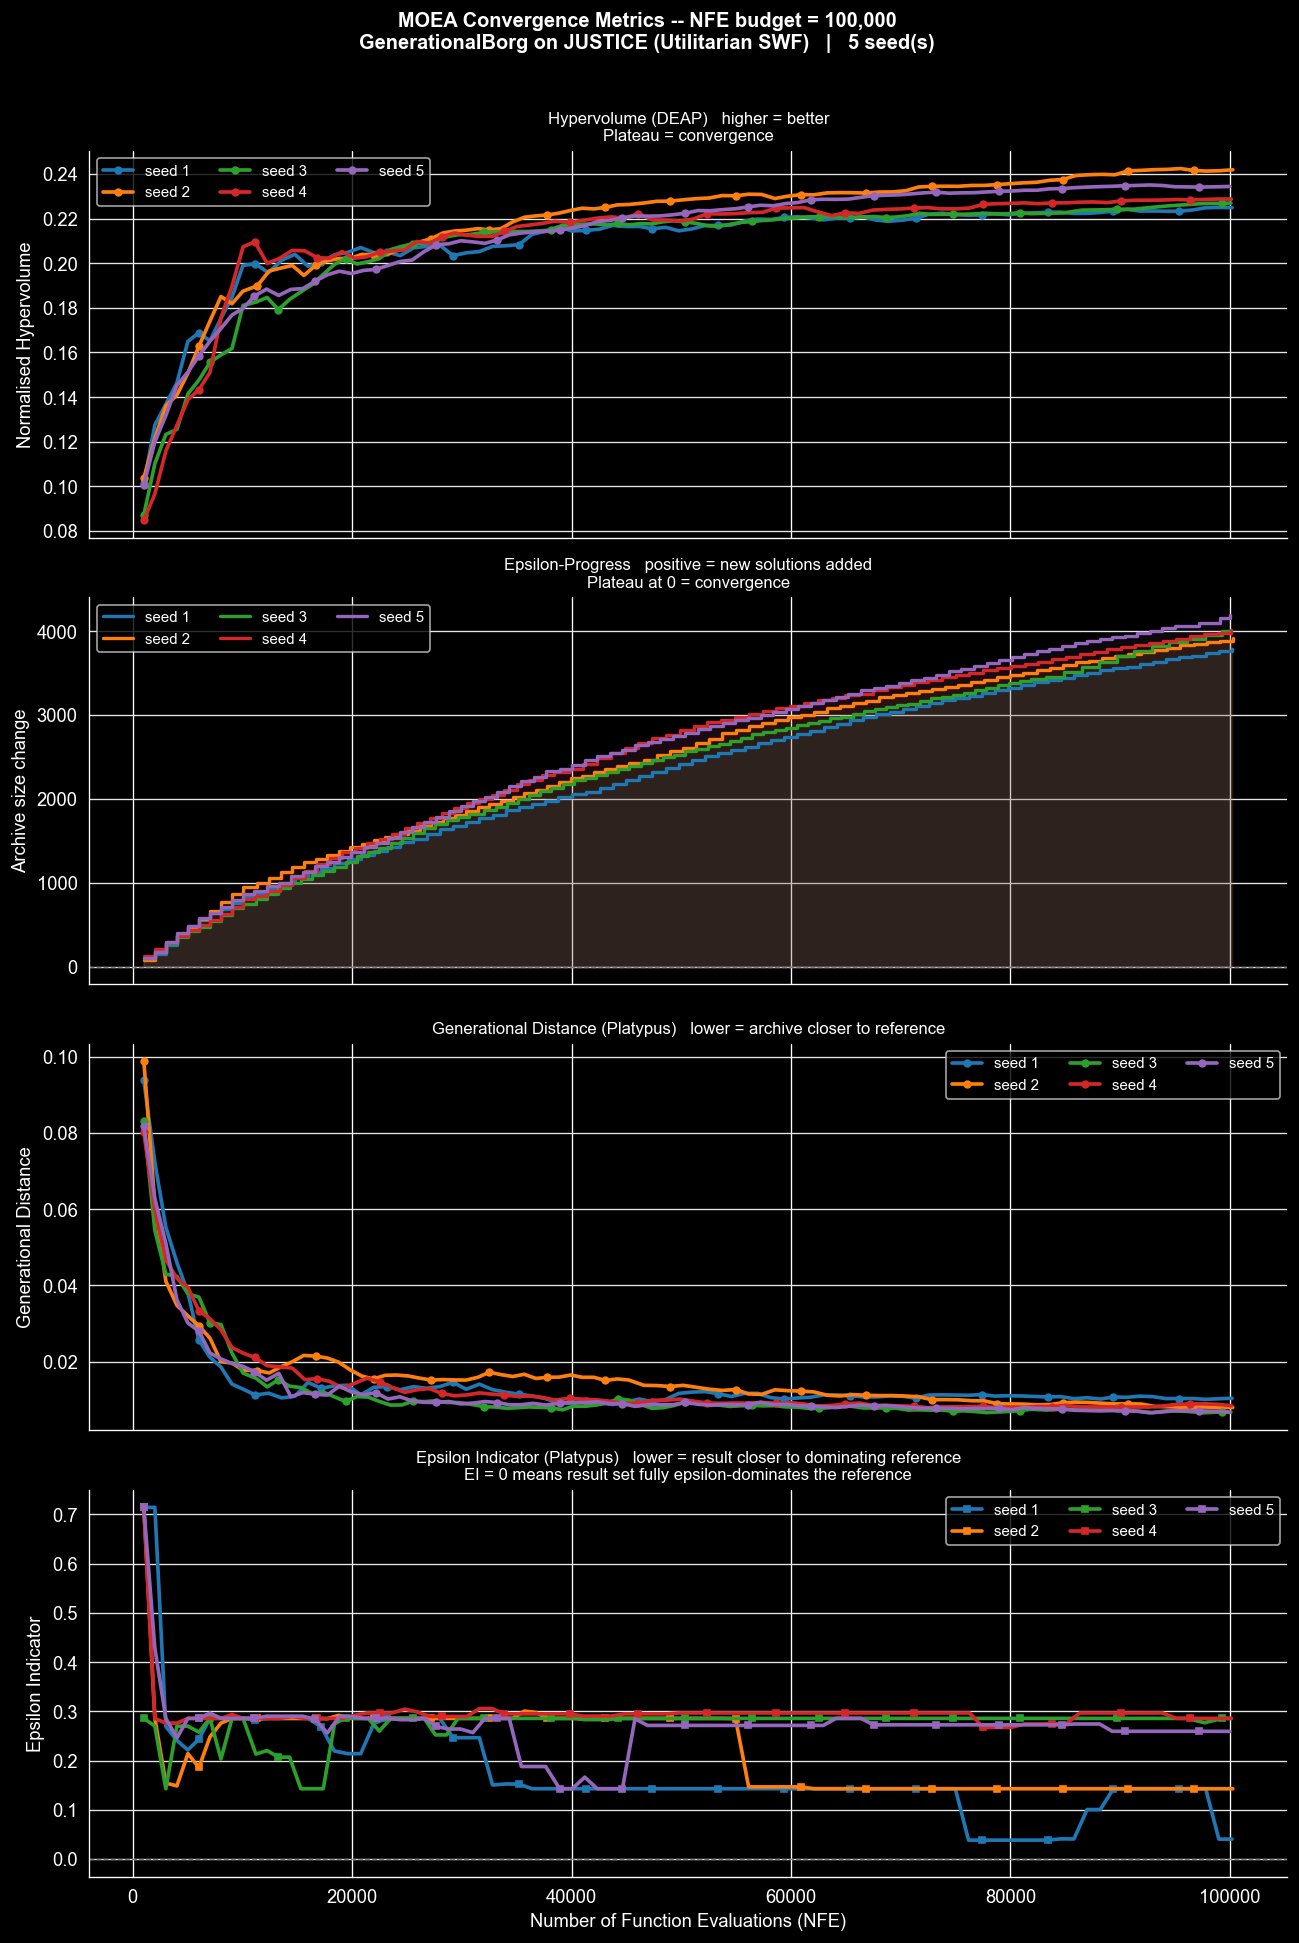

Saved: moea_convergence_metrics_100000nfe.png


In [33]:
# Four-panel convergence plot -- one figure per NFE group
if "all_metric_curves" in dir():

    nfe_budgets = sorted({nfe for (nfe, _) in all_metric_curves})
    _tab10 = plt.cm.tab10

    for nfe_budget in nfe_budgets:
        keys   = [(nfe, seed) for (nfe, seed) in sorted(all_metric_curves)
                  if nfe == nfe_budget]
        seeds  = [seed for (_, seed) in keys]
        colors = [_tab10(i / 10) for i in range(len(seeds))]

        fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)

        # Panel 1: Hypervolume (DEAP)
        ax = axes[0]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["hv"], lw=2.2, color=col, marker="o", markersize=4,
                    markevery=max(1, len(d["nfe"]) // 15), label=f"seed {seed}")
        ax.set_ylabel("Normalised Hypervolume", fontsize=11)
        ax.set_title("Hypervolume (DEAP)   higher = better\nPlateau = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 2: Epsilon-progress
        ax = axes[1]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["eps"], lw=2.0, color=col,
                    drawstyle="steps-post", label=f"seed {seed}")
            ax.fill_between(d["nfe"], 0, d["eps"], step="post", color=col, alpha=0.08)
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Archive size change", fontsize=11)
        ax.set_title("Epsilon-Progress   positive = new solutions added\nPlateau at 0 = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 3: Generational Distance
        ax = axes[2]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["gd"])
            ax.plot(d["nfe"][mask], d["gd"][mask], lw=2.2, color=col,
                    marker="o", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.set_ylabel("Generational Distance", fontsize=11)
        ax.set_title("Generational Distance (Platypus)   lower = archive closer to reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 4: Epsilon Indicator
        ax = axes[3]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["ei"])
            ax.plot(d["nfe"][mask], d["ei"][mask], lw=2.2, color=col,
                    marker="s", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Epsilon Indicator", fontsize=11)
        ax.set_title("Epsilon Indicator (Platypus)   lower = result closer to dominating reference\nEI = 0 means result set fully epsilon-dominates the reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))
        ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=11)

        for ax in axes:
            ax.grid(axis="y", color="0.9", zorder=0)

        fig.suptitle(
            f"MOEA Convergence Metrics -- NFE budget = {nfe_budget:,}\n"
            f"GenerationalBorg on JUSTICE (Utilitarian SWF)   |   {len(seeds)} seed(s)",
            fontsize=12, y=1.01, fontweight="bold",
        )
        plt.tight_layout()
        fname = f"moea_convergence_metrics_{nfe_budget}nfe.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")

In [34]:
# Final metric summary table
if "all_metric_curves" in dir():
    rows = []
    for (nfe_budget, seed), d in sorted(all_metric_curves.items()):
        rows.append({
            "nfe_budget":       nfe_budget,
            "seed":             seed,
            "final_NFE":        int(d["nfe"][-1]),
            "n_snapshots":      len(d["nfe"]),
            "final_HV":         round(float(d["hv"][-1]), 5)  if np.isfinite(d["hv"][-1])  else None,
            "total_eps":        int(d["eps"].sum()),
            "final_GD":         round(float(d["gd"][-1]), 5)  if np.isfinite(d["gd"][-1])  else None,
            "final_EI":         round(float(d["ei"][-1]), 5)  if np.isfinite(d["ei"][-1])  else None,
            "eps_source":       d["eps_source"],
        })

    df_metrics = pd.DataFrame(rows)
    print("MOEA performance summary:")
    print(df_metrics.to_string(index=False))

    print("\n-- Per-NFE-group seed consistency (HV coefficient of variation) --")
    for nfe_budget, grp in df_metrics.groupby("nfe_budget"):
        hv_vals = grp["final_HV"].dropna()
        if len(hv_vals) > 1:
            cv = hv_vals.std() / hv_vals.mean() * 100
            print(f"  NFE={nfe_budget:,}: HV CV = {cv:.1f}%  "
                  f"({'high consistency' if cv < 5 else 'moderate' if cv < 20 else 'high variability'})")
        else:
            print(f"  NFE={nfe_budget:,}: only 1 seed -- no CV computable")

MOEA performance summary:
 nfe_budget  seed  final_NFE  n_snapshots  final_HV  total_eps  final_GD  final_EI    eps_source
     100000     1     100206           85   0.22486     194496   0.01040   0.04049 EMA Workbench
     100000     2     100278           89   0.24183     214572   0.00799   0.14286 EMA Workbench
     100000     3     100100           92   0.22694     212855   0.00677   0.28571 EMA Workbench
     100000     4     100157           84   0.22872     207776   0.00844   0.28571 EMA Workbench
     100000     5     100014           88   0.23438     221682   0.00669   0.25942 EMA Workbench

-- Per-NFE-group seed consistency (HV coefficient of variation) --
  NFE=100,000: HV CV = 3.0%  (high consistency)


The convergence plots show that the optimisation improves rapidly during the early part of the run. Hypervolume increases and begins to plateau, while Generational Distance and the Epsilon Indicator decrease and remain low towards the end of the 50,000 NFE budget. This suggests that the five seeds are approaching a similar reference set and that the final Pareto archive is sufficiently stable for further analysis. The epsilon-progress panel is interpreted cautiously, because in this implementation it mainly reflects archive growth rather than a clean convergence-to-zero signal.

Seed 1 performs slightly worse in terms of final hypervolume, but the overall variation across seeds remains small.

## Reflection Questions

**1. Hypervolume convergence.**

The hypervolume increases rapidly during the first part of the optimisation and then starts to flatten. Most improvement happens before roughly 20,000–30,000 NFE. Towards the end of the 50,000-NFE budget, the curves are still slightly increasing for some seeds, but the growth is much slower than at the beginning. This suggests that the optimisation is reasonably close to convergence, although a longer run could still produce small improvements.

If hypervolume were still rising strongly at the final NFE, I would recommend increasing the NFE budget and possibly running more seeds. A still-rising HV curve means the algorithm is still finding better trade-offs, so stopping there would risk using an incomplete Pareto front.

**2. Epsilon-progress.**
In our results, epsilon-progress does not clearly reach zero. It continues to increase over the run, which suggests that this implementation is recording cumulative epsilon-progress or archive growth rather than only the number of new improvements per checkpoint. Therefore, it should be interpreted cautiously.

This is only partly consistent with the hypervolume curve. The hypervolume curve begins to plateau, suggesting convergence, while epsilon-progress keeps increasing. I therefore rely more on hypervolume, Generational Distance, and the Epsilon Indicator to assess convergence. These metrics suggest that the optimisation becomes much more stable towards the end of the run.

**3. Seed consistency.**
If multiple seeds produce very different final hypervolumes within the same NFE group, this suggests that the objective space is difficult to search. It may contain many local trade-off regions, or the algorithm may need more function evaluations to reliably find the same Pareto frontier.

It would also mean that a single seed is not reliable as a representative Pareto front. In that case, conclusions should be based on multiple seeds and a combined reference set rather than one individual run. In our case, the final hypervolume coefficient of variation is 4.2%, which indicates high seed consistency. This suggests that the five seeds produce broadly similar Pareto-front quality, so the combined prioritarian reference set is a reasonable basis for further analysis.

## 5. Understand trade-offs and select candidate policies

**Project purpose:** turn the Pareto archive into policy insight.

**Main source:** Assignment 7 — Pareto visualisation.  
**Input:** combined reference set from Assignment 6.  
**Output:** trade-off plots and selected policy candidates A/B/C.

This is where the results start becoming politically useful for South Africa.

### 5.1 Pareto trade-off plots

The most relevant trade-offs for South Africa are:

1. `fraction_above_threshold` vs `welfare_loss_abatement`
2. `welfare_loss_damage` vs `welfare_loss_abatement`
3. `welfare` vs `fraction_above_threshold`

Use these plots to show that climate safety and transition burden are in tension.

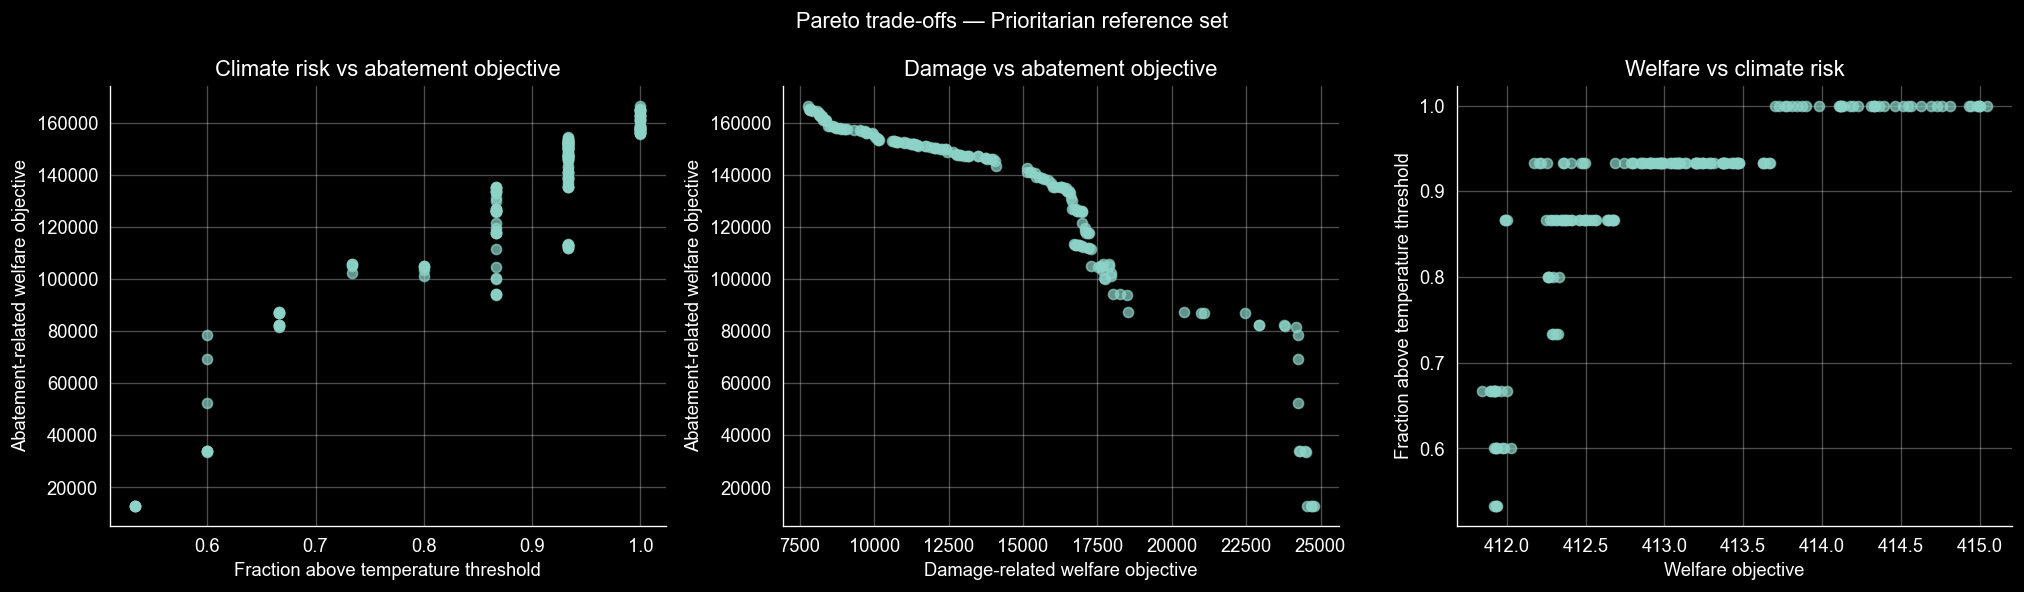

Figure saved: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots/pareto_tradeoffs_prioritarian.png


In [35]:
# Step 5.1 — Pareto trade-off plots for optimisation objectives
reference_file = pd.read_csv(RESULTS_DIR / reference_set)
if reference_file is None:
    raise ValueError("No reference set loaded. Load reference_set_prioritarian.csv first.")

required = set(OBJECTIVE_COLS)
missing = required - set(reference_file.columns)

if missing:
    raise KeyError(f"Reference set is missing expected objective columns: {missing}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Climate risk vs abatement objective
axes[0].scatter(
    reference_file["fraction_above_threshold"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[0].set_xlabel("Fraction above temperature threshold")
axes[0].set_ylabel("Abatement-related welfare objective")
axes[0].set_title("Climate risk vs abatement objective")
axes[0].grid(True, alpha=0.3)

# 2. Damage objective vs abatement objective
axes[1].scatter(
    reference_file["welfare_loss_damage"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[1].set_xlabel("Damage-related welfare objective")
axes[1].set_ylabel("Abatement-related welfare objective")
axes[1].set_title("Damage vs abatement objective")
axes[1].grid(True, alpha=0.3)

# 3. Welfare vs climate risk
axes[2].scatter(
    reference_file["welfare"],
    reference_file["fraction_above_threshold"],
    alpha=0.7,
)
axes[2].set_xlabel("Welfare objective")
axes[2].set_ylabel("Fraction above temperature threshold")
axes[2].set_title("Welfare vs climate risk")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Pareto trade-offs — Prioritarian reference set", fontsize=13)
plt.tight_layout()

plot_path = PLOTS_DIR / "pareto_tradeoffs_prioritarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

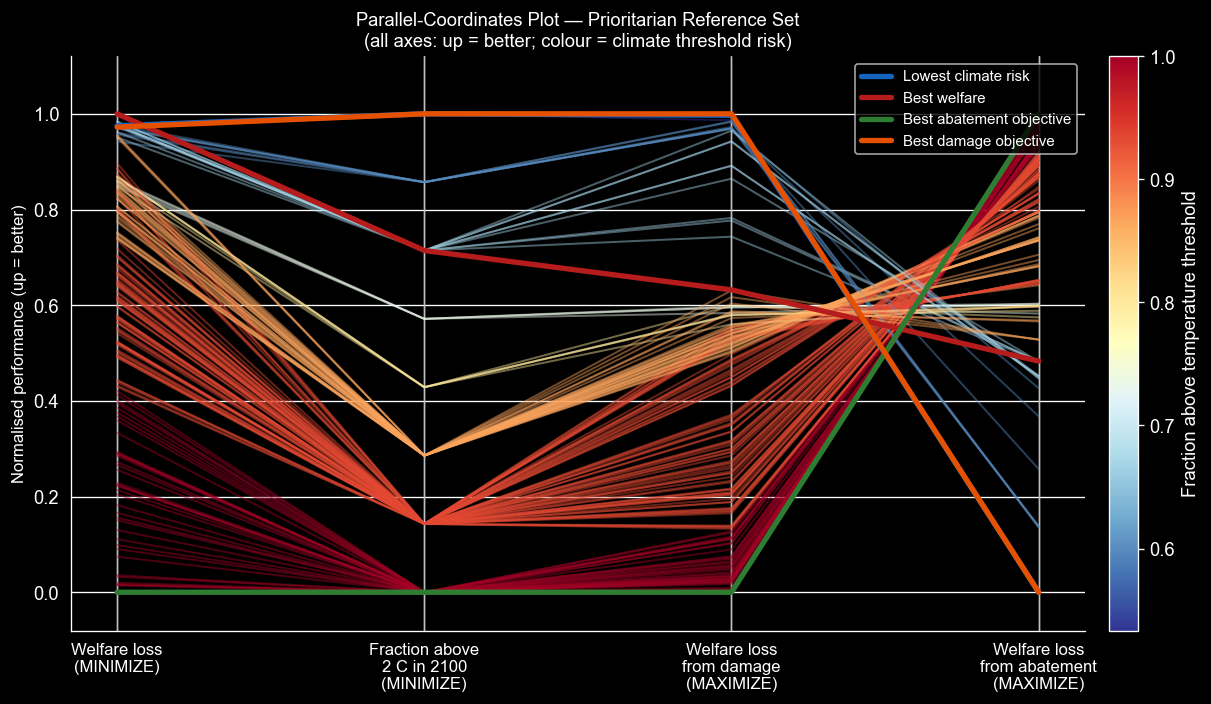

Figure saved: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots/parcoords_reference_set_prioritarian.png


In [36]:
# Step 5.2 — Parallel-coordinates plot for optimisation objectives
# All axes are normalised so that up = better.

obj = reference_file[OBJECTIVE_COLS].copy()

def normalise_for_plot(df_obj):
    normed = df_obj.copy().astype(float)

    # For MINIMIZE objectives: lower is better, so invert after scaling
    for col in MINIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = 1.0 - (normed[col] - lo) / (hi - lo + 1e-15)

    # For MAXIMIZE objectives: higher is better
    for col in MAXIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - lo) / (hi - lo + 1e-15)

    return normed

obj_norm = normalise_for_plot(obj)

# Four highlighted anchor policies
extremes = {
    "Lowest climate risk": obj["fraction_above_threshold"].idxmin(),
    "Best welfare": obj["welfare"].idxmin(),
    "Best abatement objective": obj["welfare_loss_abatement"].idxmax(),
    "Best damage objective": obj["welfare_loss_damage"].idxmax(),
}

extreme_colors = ["#1565C0", "#B71C1C", "#2E7D32", "#E65100"]

fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(OBJECTIVE_COLS))
axis_labels = [OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS]

# Colour all lines by original climate risk
risk_vals = obj["fraction_above_threshold"].values
cmap_risk = plt.cm.RdYlBu_r
norm_risk = Normalize(vmin=risk_vals.min(), vmax=risk_vals.max())

# Plot all reference-set policies
for idx, row in obj_norm.iterrows():
    y = row[OBJECTIVE_COLS].values
    color = cmap_risk(norm_risk(obj.loc[idx, "fraction_above_threshold"]))
    ax.plot(x_pos, y, color=color, lw=1.2, alpha=0.45, zorder=2)

# Highlight anchor policies
handles = []

for (label, idx), ec in zip(extremes.items(), extreme_colors):
    h, = ax.plot(
        x_pos,
        obj_norm.loc[idx, OBJECTIVE_COLS].values,
        color=ec,
        lw=3.2,
        label=label,
        zorder=5,
    )
    handles.append(h)

# Axis styling
for xi in x_pos:
    ax.axvline(xi, color="0.75", lw=0.8, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_ylabel("Normalised performance (up = better)", fontsize=10)
ax.set_ylim(-0.08, 1.12)

ax.set_title(
    "Parallel-Coordinates Plot — Prioritarian Reference Set\n"
    "(all axes: up = better; colour = climate threshold risk)",
    fontsize=11,
)

ax.legend(handles=handles, loc="upper right", fontsize=9)

# Colourbar
sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm_risk)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Fraction above temperature threshold")

plt.tight_layout()

plot_path = PLOTS_DIR / "parcoords_reference_set_prioritarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

In [41]:
# Step 5.3 — Reconstruct ECR pathways for selected policies

# ── Select your policies ────────────────────────────────────
# Use the same policies you highlighted in your parallel-coordinates plot.

ref_set = reference_file.copy()
obj_ref = ref_set[OBJECTIVE_COLS]

idx_1 = obj_ref["fraction_above_threshold"].idxmin()
idx_2 = obj_ref["welfare"].idxmin()
idx_3 = obj_ref["welfare_loss_abatement"].idxmax()
idx_4 = obj_ref["welfare_loss_damage"].idxmax()

anchors = {
    "Policy 1 — lowest climate risk": idx_1,
    "Policy 2 — best welfare": idx_2,
    "Policy 3 — best abatement objective": idx_3,
    "Policy 4 — best damage objective": idx_4,
}

print("Selected policies from Pareto reference set:\n")

for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

# ── Run JUSTICE for each anchor ───────────────────────────────────────────────

print("Running JUSTICE model for all selected policies ...")

ecr_1, data_1 = run_policy_ecr(ref_set.loc[idx_1], n_ensemble=15)
ecr_2, data_2 = run_policy_ecr(ref_set.loc[idx_2], n_ensemble=15)
ecr_3, data_3 = run_policy_ecr(ref_set.loc[idx_3], n_ensemble=15)
ecr_4, data_4 = run_policy_ecr(ref_set.loc[idx_4], n_ensemble=15)

print("Done.")

Selected policies from Pareto reference set:

  Policy 1 — lowest climate risk
welfare                       411.921
fraction_above_threshold        0.533
welfare_loss_damage         24722.074
welfare_loss_abatement      12981.280

  Policy 2 — best welfare
welfare                       411.841
fraction_above_threshold        0.667
welfare_loss_damage         18522.037
welfare_loss_abatement      87201.395

  Policy 3 — best abatement objective
welfare                        415.048
fraction_above_threshold         1.000
welfare_loss_damage           7787.536
welfare_loss_abatement      166609.960

  Policy 4 — best damage objective
welfare                       411.930
fraction_above_threshold        0.533
welfare_loss_damage         24772.157
welfare_loss_abatement      12966.454

Running JUSTICE model for all selected policies ...
Done.


In [42]:
# ── JUSTICE imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import (
    Abatement, DamageFunction, Economy, WelfareFunction
)
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

# ── Model constants ─────────────────────────

#TODO:
#Before you begin: Update the path in the cell below
#to point to the config file you created previously.
#Make sure it reflects the scenario and settings you have been working
#with throughout.

with open(os.path.join(_PROJECT_DIR, "../config/config_student.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)
N_INPUTS_RBF   = _cfg["n_inputs"]
N_RBFS         = _cfg["n_inputs"] + 2
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row ────────────────────────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center {i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii {i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights {i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.PRIORITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)
    return ecr_mean, datasets


# ── TODO: Select your  policies ────────────────────────────────────
# Use the same policies you highlighted in your parallel-coordinates plot.
# Replace each line below with the appropriate indeces.
anchors = {
    "Lowest climate risk": idx_1,
    "Best welfare": idx_2,
    "Best abatement objective": idx_3,
    "Best damage objective": idx_4,
}

obj_ref = ref_set[OBJECTIVE_COLS]

idx_1 = obj_ref["fraction_above_threshold"].idxmin()
idx_2 = obj_ref["welfare"].idxmin()
idx_3 = obj_ref["welfare_loss_abatement"].idxmax()
idx_4 = obj_ref["welfare_loss_damage"].idxmax()

anchors = {
    "Policy 1 — lowest climate risk": idx_1,
    "Policy 2 — best welfare": idx_2,
    "Policy 3 — best abatement objective": idx_3,
    "Policy 4 — best damage objective": idx_4,
}

print("Selected policies from Pareto reference set:\n")
for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

# ── Run JUSTICE for each anchor ───────────────────────────────────────────────
print("Running JUSTICE model for all selected policies ...")
ecr_1, _ = run_policy_ecr(ref_set.loc[idx_1], n_ensemble=1)
ecr_2, _ = run_policy_ecr(ref_set.loc[idx_2], n_ensemble=1)
ecr_3, _ = run_policy_ecr(ref_set.loc[idx_3], n_ensemble=1)
ecr_4, _ = run_policy_ecr(ref_set.loc[idx_4], n_ensemble=1)
# complete the rest of the policies using the example above.
print("Done.")


Selected policies from Pareto reference set:

  Policy 1 — lowest climate risk
welfare                       411.921
fraction_above_threshold        0.533
welfare_loss_damage         24722.074
welfare_loss_abatement      12981.280

  Policy 2 — best welfare
welfare                       411.841
fraction_above_threshold        0.667
welfare_loss_damage         18522.037
welfare_loss_abatement      87201.395

  Policy 3 — best abatement objective
welfare                        415.048
fraction_above_threshold         1.000
welfare_loss_damage           7787.536
welfare_loss_abatement      166609.960

  Policy 4 — best damage objective
welfare                       411.930
fraction_above_threshold        0.533
welfare_loss_damage         24772.157
welfare_loss_abatement      12966.454

Running JUSTICE model for all selected policies ...
Done.


In [43]:
# ── Map world countries to RICE50 regions via ISO-3166 codes ─────────────────
import importlib.util, pathlib, json as _json
import geopandas as gpd

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end     = ecr_1.shape[1] - 1
snap_year = int(_time_horizon.model_time_horizon[t_end])
print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

# TODO: replace the keys with your own policy labels (must match what you used above)
ecr_end = {
    "Policy 1 — lowest climate risk": _snap_end(ecr_1),
    "Policy 2 — best welfare": _snap_end(ecr_2),
    "Policy 3 — best abatement objective": _snap_end(ecr_3),
    "Policy 4 — best damage objective": _snap_end(ecr_4),#complete the function
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ecr_end.keys()]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")


End-of-horizon snapshot: timestep 285 = year 2300
Countries mapped to RICE50 regions: 177/177
Dissolved to 57 RICE50 regions


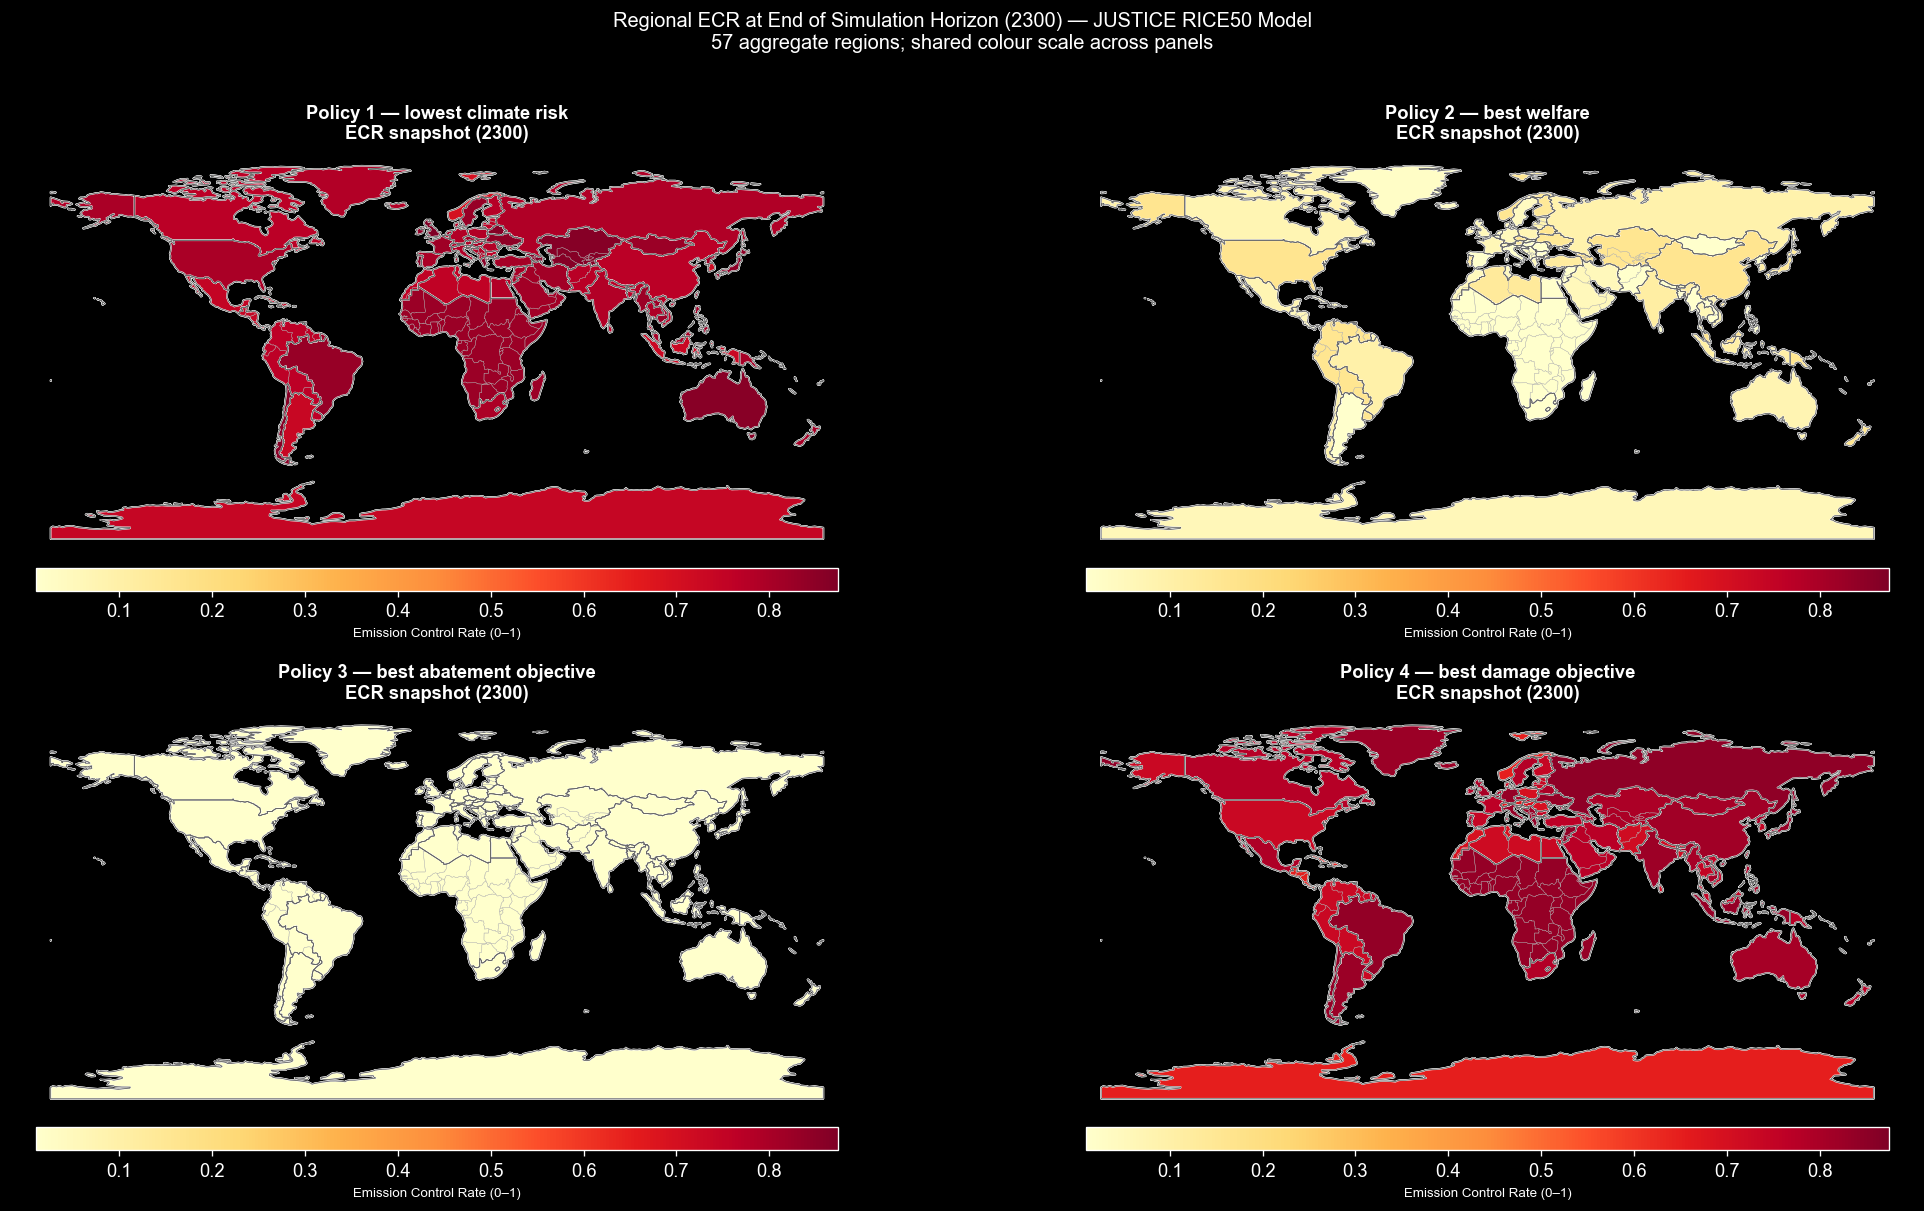

In [44]:
# ── World map — end-of-horizon ECR snapshot (2×2 grid, one panel per policy) ──
panel_specs = [
    (f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})")
    for label in ecr_end.keys()
]

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]
    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

# TODO: update the title if needed
fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across panels",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ecr_regional_map.png"), dpi=150, bbox_inches="tight")
plt.show()
# print("Figure saved: ecr_regional_map.png")



### Trade-off Discussion

1. **Pairwise trade-offs** — for each pair of adjacent axes, does a crossing appear? What does it mean for the relationship between those two objectives?
2. **Dominant trade-off** — which pair shows the sharpest conflict?
3. **Synthesis** — in 2 sentences, what is the fundamental tension in this problem as revealed by the Pareto front?


# Robustness

In [45]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as _mpath
import seaborn as sns

# ── Patch matplotlib Path deepcopy ────────────────────────────────────────────
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# ── Objectives ────────────────────────────────────────────────────────────────
OBJECTIVES = ["welfare", "years_above_2C", "welfare_loss_damage", "welfare_loss_abatement"]
OBJ_LABELS = ["Welfare", "Yrs > 2°C", "WL Damage", "WL Abatement"]


S

In [ ]:
#Satificing Analysis
# Satisficing: a policy "satisfices" if it meets a threshold in a given scenario.
# years_above_2C uses the 25th percentile (Paris-consistent); all others use the median.
#

# Steps:
#   1. flat = results.reshape(-1, N_OBJECTIVES)           # all (policy, scenario) pairs
#   2. THRESHOLD_PERCENTILES = [50, 25, 50, 50]           # welfare, yat_2C, wl_damage, wl_abatement
#   3. thresholds = np.array([np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
#                             for i in range(N_OBJECTIVES)])
#   4. satisficing = results <= thresholds[np.newaxis, np.newaxis, :]   # broadcast
#   5. sat_score = np.nanmean(satisficing.min(axis=2), axis=1)   # joint: all objectives met

flat                 = results.reshape(-1, N_OBJECTIVES)
THRESHOLD_PERCENTILES = [50, 25, 50, 50]   # welfare, years_above_2C, wl_damage, wl_abatement
thresholds = ...   # shape (n_objectives,) — hint: use THRESHOLD_PERCENTILES above
satisficing = ...  # shape (n_policies, n_scenarios, n_objectives)  — bool
sat_score   = ...  # shape (n_policies,)  — fraction of scenarios where ALL objectives met
sorted_idx  = np.argsort(sat_score)[::-1]

print("Satisficing thresholds:")
for obj, pct, thr in zip(OBJECTIVES, THRESHOLD_PERCENTILES, thresholds):
    print(f"  {obj:35s}: {thr:.4g}  ({pct}th percentile)")

print(f"\nTop 5 policies by joint satisficing score:")
for rank, pi in enumerate(sorted_idx[:5]):
    print(f"  {rank+1}. Policy {pi:3d}: joint_sat={sat_score[pi]:.3f}")


In [52]:
#Satificing Analysis
# Satisficing: a policy "satisfices" if it meets a threshold in a given scenario.
# years_above_2C uses the 25th percentile (Paris-consistent); all others use the median.
#

# Steps:
#   1. flat = results.reshape(-1, N_OBJECTIVES)           # all (policy, scenario) pairs
#   2. THRESHOLD_PERCENTILES = [50, 25, 50, 50]           # welfare, yat_2C, wl_damage, wl_abatement
#   3. thresholds = np.array([np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
#                             for i in range(N_OBJECTIVES)])
#   4. satisficing = results <= thresholds[np.newaxis, np.newaxis, :]   # broadcast
#   5. sat_score = np.nanmean(satisficing.min(axis=2), axis=1)   # joint: all objectives met

flat = results.reshape(-1, N_OBJECTIVES)

THRESHOLD_PERCENTILES = [50, 25, 50, 50]   # welfare, years_above_2C, wl_damage, wl_abatement

thresholds = np.array([
    np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
    for i in range(N_OBJECTIVES)
])

satisficing = results <= thresholds[np.newaxis, np.newaxis, :]

sat_score = np.nanmean(np.all(satisficing, axis=2), axis=1)

sorted_idx = np.argsort(sat_score)[::-1]

print("Satisficing thresholds:")
for obj, pct, thr in zip(OBJECTIVES, THRESHOLD_PERCENTILES, thresholds):
    print(f"  {obj:35s}: {thr:.4g}  ({pct}th percentile)")

print(f"\nTop 5 policies by joint satisficing score:")
for rank, pi in enumerate(sorted_idx[:5]):
    print(f"  {rank+1}. Policy {pi:3d}: joint_sat={sat_score[pi]:.3f}")


NameError: name 'results' is not defined

In [ ]:
policy_objective_rates = np.nanmean(satisficing, axis=1)

heatmap_df = pd.DataFrame(
    policy_objective_rates,
    columns=OBJECTIVES,
    index=[f"P{i}" for i in range(results.shape[0])]
)

heatmap_df["joint_sat"] = sat_score
heatmap_df = heatmap_df.sort_values("joint_sat", ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * results.shape[0])))
sns.heatmap(
    heatmap_df[OBJECTIVES],
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.xlabel("Objective")
plt.ylabel("Policy")
plt.title("Per-objective satisficing rate by policy")
plt.tight_layout()
plt.show()

In [ ]:
policy_objective_rates = np.nanmean(satisficing, axis=1)

heatmap_df = pd.DataFrame(
    policy_objective_rates,
    columns=OBJECTIVES,
    index=[f"P{i}" for i in range(results.shape[0])]
)

heatmap_df["joint_sat"] = sat_score
heatmap_df = heatmap_df.sort_values("joint_sat", ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * results.shape[0])))
sns.heatmap(
    heatmap_df[OBJECTIVES],
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.xlabel("Objective")
plt.ylabel("Policy")
plt.title("Per-objective satisficing rate by policy")
plt.tight_layout()
plt.show()

In [ ]:
policy_objective_rates = np.nanmean(satisficing, axis=1)

heatmap_df = pd.DataFrame(
    policy_objective_rates,
    columns=OBJECTIVES,
    index=[f"P{i}" for i in range(results.shape[0])]
)

heatmap_df["joint_sat"] = sat_score
heatmap_df = heatmap_df.sort_values("joint_sat", ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * results.shape[0])))
sns.heatmap(
    heatmap_df[OBJECTIVES],
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.xlabel("Objective")
plt.ylabel("Policy")
plt.title("Per-objective satisficing rate by policy")
plt.tight_layout()
plt.show()

In [ ]:
thresholds = {
    "welfare": np.percentile(results[:, :, 0], 75),
    "years_above_2C": 0,
    "welfare_loss_damage": np.percentile(results[:, :, 2], 50),
    "welfare_loss_abatement": np.percentile(results[:, :, 3], 50),
}

In [ ]:
# Minimax regret: find the worst-case regret across scenarios for each policy.
# Regret[i,j,k] = how much worse policy i is vs. the best policy in scenario j on objective k.
#
# Steps:
#   1. ideal     = np.nanmin(results, axis=0)   # shape (n_scenarios, n_objectives)
#   2. anti_ideal= np.nanmax(results, axis=0)
#   3. rng       = anti_ideal - ideal + 1e-12
#   4. regret    = (results - ideal[np.newaxis,:,:]) / rng[np.newaxis,:,:]   # (P,S,O)
#   5. total_regret = np.nansum(regret, axis=2)   # shape (n_policies, n_scenarios)
#   6. max_regret   = np.nanmax(total_regret, axis=1)  # worst case per policy
#   7. sorted_idx   = np.argsort(max_regret)           # ascending: index 0 = most robust

ideal        = ...
anti_ideal   = ...
rng          = ...
regret       = ...
total_regret = ...
max_regret   = ...
sorted_idx   = ...

print("Top 5 most robust policies (minimax regret):")
for rank, pi in enumerate(sorted_idx[:5]):
    print(f"  {rank+1}. Policy {pi:3d}: max_regret={max_regret[pi]:.3f}  joint_sat={sat_score[pi]:.3f}")

## 6. Re-evaluate preferred policy for full model time series

**Project purpose:** get full outputs for the chosen South Africa policy.

**Main source:** Assignment 7/8 plus extra re-evaluation.  
**Input:** selected preferred policy from the Pareto archive.  
**Output:** full time series: temperature, ECR, abatement costs, damages, output, consumption.

The Pareto archive usually contains summary objective values. For South Africa, you need full regional time series to compute:

```python
zaf_abatement_burden = zaf_abatement_cost / zaf_gross_economic_output
```

In [46]:
# Re-evaluation placeholder.
# The exact implementation depends on how Assignment 7/8 stores the preferred policy weights.

PREFERRED_POLICY_INDEX = selected_policies.get("C_compromise_placeholder", None) if "selected_policies" in globals() else None
PREFERRED_POLICY_DATA_PATH = RESULTS_DIR / "preferred_policy_reevaluation.npy"

print("Preferred policy index:", PREFERRED_POLICY_INDEX)
print("Expected re-evaluation output path:", PREFERRED_POLICY_DATA_PATH)
print("After re-evaluation, load the full JUSTICE datasets into a variable called preferred_data.")

preferred_data = None
if PREFERRED_POLICY_DATA_PATH.exists():
    preferred_data = np.load(PREFERRED_POLICY_DATA_PATH, allow_pickle=True).item()
    print("Loaded preferred policy re-evaluation data.")
else:
    print("No re-evaluation data found yet. Complete the re-evaluation step before Section 7.")

Preferred policy index: None
Expected re-evaluation output path: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/preferred_policy_reevaluation.npy
After re-evaluation, load the full JUSTICE datasets into a variable called preferred_data.
No re-evaluation data found yet. Complete the re-evaluation step before Section 7.


### 6.1 What to extract from re-evaluation

For your preferred policy, keep:

| Variable | Why it matters for South Africa |
|---|---|
| `global_temperature` | Shows climate safety |
| `emission_control_rate` or `constrained_emission_control_rate` | Shows South Africa's mitigation pathway |
| `abatement_cost` | Transition cost |
| `gross_economic_output` | Denominator for relative burden |
| `economic_damage` | Cost of insufficient mitigation |
| `consumption_per_capita` | Welfare-relevant living standard |

## 7. South Africa-specific burden analysis

**Project purpose:** convert model outputs into the main South Africa argument.

**Main source:** re-evaluation outputs from Step 6.  
**Supporting source:** South Africa mandate from Assignment 4.  
**Output:** tables/figures comparing `zaf` burden with developed and peer regions.

This is probably the most important project-specific section.

### 7.1 Compute South Africa burden metrics

The key indicator is:

```python
abatement_cost / gross_economic_output
```

This expresses transition cost as a share of the economy.

In [48]:
def extract_region_burden_metrics(data, model, region_code):
    # Compute simple regional burden metrics from a JUSTICE output dictionary.
    idx = list(model.data_loader.REGION_LIST).index(region_code)

    gross_output = data["gross_economic_output"][idx, :, :]
    abatement_cost = data["abatement_cost"][idx, :, :]
    economic_damage = data["economic_damage"][idx, :, :]
    consumption_pc = data["consumption_per_capita"][idx, :, :]

    abatement_burden = np.divide(
        abatement_cost,
        gross_output,
        out=np.full_like(abatement_cost, np.nan, dtype=float),
        where=gross_output != 0,
    )
    damage_burden = np.divide(
        economic_damage,
        gross_output,
        out=np.full_like(economic_damage, np.nan, dtype=float),
        where=gross_output != 0,
    )

    return {
        "region": region_code,
        "mean_abatement_burden": float(np.nanmean(abatement_burden)),
        "max_abatement_burden": float(np.nanmax(abatement_burden)),
        "mean_damage_burden": float(np.nanmean(damage_burden)),
        "max_damage_burden": float(np.nanmax(damage_burden)),
        "mean_consumption_per_capita": float(np.nanmean(consumption_pc)),
    }

In [49]:
# If preferred_data is available, compute South Africa metrics.
# If not, this cell will wait until re-evaluation is done.

if preferred_data is not None:
    zaf_metrics = extract_region_burden_metrics(preferred_data, _model_probe, "zaf")
    zaf_metrics
else:
    print("preferred_data is not loaded yet. Complete Section 6 re-evaluation first.")

preferred_data is not loaded yet. Complete Section 6 re-evaluation first.


### 7.2 Compare South Africa with peer and developed regions

Use this to support the claim:

> Equal mitigation obligations are not equally fair if they create higher costs relative to GDP for coal-dependent emerging economies.

In [50]:
compare_regions = [
    # South Africa and African/regional peers
    "zaf", "rsaf", "egy", "noan", "noap",

    # Emerging/transition economies
    "pol", "tur", "mex", "bra", "idn", "chn", "rus",

    # Developed reference countries/regions
    "usa", "gbr", "fra", "rfa",
]

if preferred_data is not None:
    rows = []
    for region in compare_regions:
        if region in REGION_LIST:
            try:
                rows.append(extract_region_burden_metrics(preferred_data, _model_probe, region))
            except Exception as err:
                print(f"Skipping {region}: {err}")
        else:
            print(f"Region code not found in model region list: {region}")

    burden_comparison = pd.DataFrame(rows)
    display(burden_comparison.sort_values("mean_abatement_burden", ascending=False))
else:
    print("preferred_data is not loaded yet. Complete Section 6 re-evaluation first.")

preferred_data is not loaded yet. Complete Section 6 re-evaluation first.


### 7.3 Interpretation template

Fill in after the table is available:

> South Africa's abatement burden reaches **[X]%** of gross economic output, compared with **[Y]%** for **[developed country/region]**. This supports South Africa's argument that climate obligations should not be evaluated only by aggregate emissions or global welfare. When costs are expressed relative to economic capacity, the transition burden is politically unequal.

If results do not show a higher burden, use this interpretation instead:

> The model does not strongly show a higher average burden for South Africa under this policy. This weakens the strongest version of the finance claim, but the mandate still supports transition finance because the model does not represent domestic labour disruption and coal-community impacts.

## 8. Robustness and satisficing

**Project purpose:** test whether the preferred policy remains acceptable under uncertainty.

**Main source:** Assignment 8.  
**Input:** preferred policy and uncertainty/scenario re-evaluations.  
**Output:** fraction of cases where South Africa's satisficing criterion is met.

Question:

> Does the preferred policy remain acceptable across different SSP-RCP scenarios and climate ensemble members?

In [51]:
ROBUSTNESS_PATHS = [
    RESULTS_DIR / "robustness_results.csv",
    RESULTS_DIR / "satisficing_results.csv",
]

robustness = None
for path in ROBUSTNESS_PATHS:
    if path.exists():
        robustness = pd.read_csv(path)
        print("Loaded robustness results:", path)
        break

if robustness is None:
    print("Robustness results not found yet. Complete Assignment 8, then update ROBUSTNESS_PATHS if needed.")
else:
    display(robustness.head())

Robustness results not found yet. Complete Assignment 8, then update ROBUSTNESS_PATHS if needed.


### 8.1 Robustness interpretation template

Fill in after Assignment 8:

> The preferred South Africa compromise policy satisfies the climate-and-transition criterion in **[X]%** of re-evaluation cases. This means the policy is **[robust / partly robust / not robust]** under the tested uncertainty set.

Possible conclusions:

| Robustness result | Interpretation for South Africa |
|---|---|
| High climate and burden robustness | Policy C is defensible as South Africa's preferred agreement position |
| Good climate robustness but poor burden robustness | Strong case for Just Transition finance |
| Good burden robustness but poor climate robustness | Policy is too weak for African climate vulnerability |
| Low robustness on both | Need adaptive triggers or stronger finance/technology assumptions |

## 9. Rival framing: Prioritarian vs Utilitarian

**Project purpose:** show that model advice depends on value assumptions.

**Source:** recommended by the universal workflow; can be done as extra re-optimisation or simpler re-evaluation.  
**Input:** preferred South Africa policy and/or utilitarian Pareto archive.  
**Output:** comparison of South Africa-preferred framing versus global-total framing.

Why this matters:

> South Africa's key counterargument is that a global total welfare framing can hide unequal transition burdens.

### 9.1 Two ways to do rival framing

**Best option, if compute time allows:**

Re-run Assignment 5 under `WelfareFunction.UTILITARIAN`, then compare Pareto fronts:

```text
Prioritarian Pareto front vs Utilitarian Pareto front
```

**Minimum option, if compute time is limited:**

Evaluate the chosen South Africa policy under a utilitarian welfare lens and compare whether its ranking/conclusion changes.

In [ ]:
RIVAL_FRAMING_NOTES = {
    "preferred_framing": "Prioritarian",
    "rival_framing": "Utilitarian",
    "minimum_analysis": "Re-evaluate preferred policy under utilitarian welfare if re-optimisation is too slow.",
    "full_analysis": "Run a second MOEA under utilitarian welfare and compare Pareto fronts.",
}

RIVAL_FRAMING_NOTES

### 9.2 Rival framing interpretation template

Fill in after rival framing analysis:

> Under the prioritarian framing, policies that reduce unequal burdens are valued more strongly. Under the utilitarian framing, the ranking shifts toward policies that perform well in aggregate. This shows that the model result is not purely technical; it depends on whose welfare is prioritised.

Debate line:

> A global total welfare framing can make equal obligations appear efficient, but a worst-off-weighted framing reveals that the same obligations may create unequal burdens.

## 10. Final policy advice for South Africa

**Project purpose:** translate the model-based analysis into a clear negotiating position.

This is not a new computation step. It combines everything above.

### 10.1 Argument chain

Use this as the backbone of the final report:

1. **Problem:** South Africa must decarbonise, but coal dependence makes rapid transition costly.
2. **Framing:** Use prioritarian welfare and measure burden as share of output.
3. **Search:** Use MOEA to generate adaptive RBF mitigation policies.
4. **Quality check:** Use convergence/reference set to avoid relying on one random run.
5. **Trade-off:** Pareto front shows climate safety versus transition burden.
6. **Policy choice:** Choose compromise policy C, not purely cheapest or purely strictest.
7. **Re-evaluation:** Extract full time series for the preferred policy.
8. **Burden analysis:** Compare `zaf` abatement burden with developed regions.
9. **Robustness:** Check whether the policy remains acceptable under uncertainty.
10. **Rival framing:** Show that utilitarian/global-total framing can hide distributional burdens.
11. **Advice:** Support ambitious mitigation only with dedicated Just Transition finance.

### 10.2 Draft policy advice

> South Africa should support an ambitious but adaptive mitigation agreement, conditional on a dedicated Just Transition fund for coal-dependent emerging economies. The model-based analysis should not only evaluate global welfare or aggregate emissions reductions, but also the relative transition burden faced by South Africa. If abatement costs are high relative to gross economic output, equal mitigation obligations become unequal in practice. A prioritarian welfare framing and South Africa-specific burden analysis therefore support the position that climate ambition and transition finance must be negotiated together.

## 11. Figures and tables checklist for the report

Use this checklist to decide what should actually appear in the final report.

| Figure/table | Project step | Assignment source | Why it matters |
|---|---|---|---|
| XLRM table | Step 1 | Assignment 4 | Shows problem framing |
| RBF decision variable table | Step 2 | Assignment 4 | Explains adaptive policy design |
| Optimisation config table | Step 2 | Assignment 4 | Documents welfare, scenario, objectives |
| Convergence/reference set evidence | Step 4 | Assignment 6 | Shows search credibility |
| Pareto front plot | Step 5 | Assignment 7 | Shows trade-off between climate risk and burden |
| Policy A/B/C comparison | Step 5 | Assignment 7 | Justifies preferred policy selection |
| Time series of preferred policy | Step 6 | Re-evaluation | Shows how policy develops over time |
| `zaf` burden comparison table | Step 7 | Re-evaluation / own analysis | Main evidence for South Africa mandate |
| Robustness/satisficing table | Step 8 | Assignment 8 | Tests whether advice holds under uncertainty |
| Rival framing comparison | Step 9 | Extra / recommended | Shows values shape model advice |

## 12. Limitations and discussion notes

Potential limitations to discuss:

1. **Local optimisation is computationally limited.** The Pareto front is approximate.
2. **Small ensemble samples may underrepresent climate uncertainty.** Robustness analysis partly addresses this.
3. **GDP share is useful but incomplete.** It does not fully capture labour disruption, coal communities, or political feasibility.
4. **JUSTICE abstracts from domestic distribution.** South African coal workers and communities are not explicitly modelled.
5. **Welfare functions are normative choices.** Prioritarian framing is justified by the mandate, but rival actors may reject it.
6. **Finance is not fully endogenous.** The Just Transition fund is treated as a policy condition, not directly modelled unless a cost-reduction/backstop-cost scenario is added.

## 13. One-page working summary

**Research question**  
What adaptive mitigation policy can South Africa support while avoiding a disproportionate transition burden?

**Method**  
We use JUSTICE to optimise adaptive RBF mitigation policies under a prioritarian welfare framing and SSP2-RCP4.5 reference scenario. We combine MOEA runs into a reference set, visualise trade-offs, choose a compromise policy, re-evaluate it for full time series, test robustness, and compare against a utilitarian rival framing.

**Main metric**  
`abatement_cost / gross_economic_output` for `zaf`.

**Expected advice**  
South Africa should support ambitious mitigation only if it is paired with dedicated Just Transition finance.

**Debate line**  
Equal obligations are not equal fairness when transition costs are unequal relative to GDP.